# Workshop 2 — Problema 1: Detección de Fatiga Muscular en Ciclismo
**Universidad EAFIT — Introducción a la Inteligencia Artificial 2026-01**

Dataset: `YominE/Muscle_Fatigue_Cycling` — Señales EMG de 8 músculos durante sprints en bicicleta.

---
### Tabla de contenidos
1. Análisis Preliminar del Problema
2. Feature Engineering (Extracción de Características)
3. Análisis Exploratorio de Datos (EDA)
4. Procesamiento de Datos y División Train/Val/Test
5. Entrenamiento y Comparación de Modelos (kNN, DT, RF, GB, **DNN**)
6. Evaluación Final del Mejor Modelo
7. Prueba con Muestra Artificial


## Instalación y librerías

Instalamos la librería `datasets` de Hugging Face para cargar el dataset directamente desde la nube.

In [38]:
# Instalar dependencias necesarias
!pip install datasets -q
!pip install tensorflow -q  

In [39]:
# ─────────────────────────────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────────────────────────────
# numpy y pandas: manejo de arrays y dataframes
import numpy as np
import pandas as pd

# matplotlib y seaborn: visualización
import matplotlib.pyplot as plt
import seaborn as sns

# scipy: transformada de Fourier para dominio frecuencia
from scipy.fft import fft, fftfreq

# datasets: carga del dataset desde HuggingFace
from datasets import load_dataset

# scikit-learn: preprocesamiento, modelos clásicos, métricas
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# TensorFlow/Keras: para la Red Neuronal Profunda (DNN)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

# Semilla global para reproducibilidad
random_state = 42
np.random.seed(random_state)
tf.random.set_seed(random_state)

FS = 1000  # Frecuencia de muestreo: 1000 Hz (cada muestra = 0.001 segundos)
print('Librerías cargadas correctamente ✓')
print(f'TensorFlow versión: {tf.__version__}')


Librerías cargadas correctamente ✓
TensorFlow versión: 2.21.0


## Punto 1 — Análisis Preliminar del Problema

### ¿Qué es la fatiga muscular en ciclismo?
Durante un sprint en bicicleta, los músculos generan señales eléctricas que se pueden capturar con electrodos en la piel (electromiografía o EMG). A medida que el músculo se fatiga:
- Las señales EMG aumentan en amplitud (el cuerpo recluta más fibras musculares para compensar)
- Las frecuencias de la señal disminuyen (la conducción nerviosa se vuelve más lenta)

Este problema consiste en **clasificar automáticamente** cada ventana de tiempo como "condición normal" (Target=0) o "desgaste muscular" (Target=1).


### Punto 1a — Descarga y preprocesamiento del target

In [40]:
# ─────────────────────────────────────────────────────────────────
# DESCARGA DEL DATASET
# load_dataset('nombre') descarga el dataset de HuggingFace Hub
# .to_pandas() lo convierte a un DataFrame de pandas
# ─────────────────────────────────────────────────────────────────
print('Descargando dataset (puede tardar 3-5 min, son ~499 MB)...')
dataset = load_dataset('YominE/Muscle_Fatigue_Cycling')

# El dataset tiene una sola partición llamada 'train'
df_raw = dataset['train'].to_pandas()

print(f'✓ Shape: {df_raw.shape}')
print(f'Columnas: {df_raw.columns.tolist()}')
df_raw.head()


Descargando dataset (puede tardar 3-5 min, son ~499 MB)...
✓ Shape: (3002137, 10)
Columnas: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


In [41]:
# ─────────────────────────────────────────────────────────────────
# PREPROCESAMIENTO DEL TARGET
#
# El dataset original tiene 3 etiquetas:
#   0 → condición muscular normal
#   1 → desgaste muscular moderado
#   2 → desgaste muscular severo
#
# Según las instrucciones del profesor, unificamos 1 y 2 en una
# sola clase de "desgaste muscular" para convertirlo en
# clasificación BINARIA (más simple e interpretable).
# ─────────────────────────────────────────────────────────────────
df = df_raw.copy()

print('=== TARGET ANTES del preprocesamiento ===')
print(df['Target'].value_counts())
print(f'Valores únicos: {sorted(df["Target"].unique())}')

# replace(2, 1) cambia todos los 2 por 1 en la columna Target
df['Target'] = df['Target'].replace(2, 1)

print('\n=== TARGET DESPUÉS del preprocesamiento ===')
print(df['Target'].value_counts())
print(f'Valores únicos: {sorted(df["Target"].unique())}')
print('\n→ Clase 0: Condición normal | Clase 1: Desgaste muscular (fusión de etiquetas 1 y 2)')
print(f'\nDesbalance: {df["Target"].value_counts()[0] / df["Target"].value_counts()[1]:.2f}:1 (normal:fatiga)')
print('   Este desbalance es esperable — en una sesión de ciclismo hay más tiempo en condición normal.')


=== TARGET ANTES del preprocesamiento ===
Target
0    2127600
1     631200
2     243337
Name: count, dtype: int64
Valores únicos: [0, 1, 2]

=== TARGET DESPUÉS del preprocesamiento ===
Target
0    2127600
1     874537
Name: count, dtype: int64
Valores únicos: [0, 1]

→ Clase 0: Condición normal | Clase 1: Desgaste muscular (fusión de etiquetas 1 y 2)

Desbalance: 2.43:1 (normal:fatiga)
   Este desbalance es esperable — en una sesión de ciclismo hay más tiempo en condición normal.


### Punto 1b — Clasificación de variables

In [42]:
# ─────────────────────────────────────────────────────────────────
# CLASIFICACIÓN DE VARIABLES
#
# En Machine Learning es fundamental entender qué tipo de dato
# es cada columna antes de procesarlo:
#
#   Numérica continua: puede tomar cualquier valor real (ej: voltaje)
#   Categórica nominal: clases sin orden (ej: rojo/azul/verde)
#   Binaria: solo dos valores posibles (0 o 1)
# ─────────────────────────────────────────────────────────────────
signal_cols = [col for col in df.columns if col not in ['Time', 'Target']]

print('=== CLASIFICACIÓN DE VARIABLES ===')
print(f'\nDataset: {df.shape[0]:,} filas × {df.shape[1]} columnas\n')

print('── Variable TIEMPO ──────────────────────────────────────────')
print(f'  Columna: Time')
print(f'  Tipo: Numérica continua (float64)')
print(f'  Rango: {df["Time"].min():.3f} s → {df["Time"].max():.3f} s')
paso = df['Time'].diff().median()
print(f'  Paso temporal: {paso:.4f} s → Frecuencia de muestreo: {1/paso:.0f} Hz')
print(f'  ROL: Índice temporal. NO se usará como feature de entrada.')
print(f'  Razón: su correlación lineal con el target artificialmente simplificaría el problema.')

print(f'\n── Variables de SEÑAL EMG ({len(signal_cols)} canales) ──────────────────')
for col in signal_cols:
    print(f'  [{col}]')
    print(f'    Tipo: Numérica continua (float64) — voltaje en milivoltios')
    print(f'    Rango: [{df[col].min():.4f}, {df[col].max():.4f}] mV')
    print(f'    Nulos: {df[col].isnull().sum()}')
print(f'  → Son los predictores: a partir de estas señales se predice la fatiga.')

print(f'\n── Variable TARGET ──────────────────────────────────────────')
print(f'  Tipo: Binaria (0 o 1) → problema de CLASIFICACIÓN BINARIA')
print(f'  0 = Condición normal    → {df["Target"].value_counts()[0]:,} muestras ({df["Target"].value_counts(normalize=True)[0]*100:.1f}%)')
print(f'  1 = Desgaste muscular   → {df["Target"].value_counts()[1]:,} muestras ({df["Target"].value_counts(normalize=True)[1]*100:.1f}%)')


=== CLASIFICACIÓN DE VARIABLES ===

Dataset: 3,002,137 filas × 10 columnas

── Variable TIEMPO ──────────────────────────────────────────
  Columna: Time
  Tipo: Numérica continua (float64)
  Rango: 0.000 s → 1741.598 s
  Paso temporal: 0.0010 s → Frecuencia de muestreo: 1000 Hz
  ROL: Índice temporal. NO se usará como feature de entrada.
  Razón: su correlación lineal con el target artificialmente simplificaría el problema.

── Variables de SEÑAL EMG (8 canales) ──────────────────
  [Right Rectus femoris]
    Tipo: Numérica continua (float64) — voltaje en milivoltios
    Rango: [-0.8433, 0.9921] mV
    Nulos: 0
  [Left Gluteus maximus]
    Tipo: Numérica continua (float64) — voltaje en milivoltios
    Rango: [-1.1173, 1.0632] mV
    Nulos: 0
  [Left Gastrocnemius medialis]
    Tipo: Numérica continua (float64) — voltaje en milivoltios
    Rango: [-1.7493, 1.6148] mV
    Nulos: 0
  [Left Semitendinosus]
    Tipo: Numérica continua (float64) — voltaje en milivoltios
    Rango: [-1.5760,

## Punto 2 — Feature Engineering (Extracción de Características)

### ¿Por qué no usamos las señales crudas directamente?

Las señales EMG son series de tiempo con 1000 muestras por segundo. Alimentar 1000 valores por canal a un clasificador clásico sería:
- **Costoso computacionalmente** (dimensionalidad muy alta)
- **Ruidoso** (cada muestra individual tiene mucho ruido)

La solución es extraer **características resumidas** de ventanas de 1 segundo que capturen los patrones relevantes de fatiga.

### Justificación de cada característica

**Dominio del tiempo:**
- **RMS** (Root Mean Square): mide la "potencia" de la señal. En fatiga, el músculo recluta más fibras → mayor RMS.
- **Varianza**: mide cuán dispersa es la señal. Mayor variabilidad = señal más irregular, típica de fatiga.
- **ZCR** (Zero Crossing Rate): cruces por cero por segundo. Con fatiga, la señal se vuelve más lenta → menos cruces.
- **Pendiente media (MAV de derivada)**: velocidad de cambio entre muestras. Captura la dinámica de la señal.
- **MAV** (Mean Absolute Value): valor absoluto medio. Indicador clásico de amplitud en EMG.

**Dominio de la frecuencia:**
- **Frecuencia mediana**: el indicador más importante en fatiga muscular. Baja consistentemente durante el desgaste (estándar clínico).
- **Frecuencia media**: complementa la mediana. También disminuye con fatiga.
- **Potencia espectral total**: energía total de la señal. Puede aumentar con fatiga por mayor reclutamiento muscular.


In [43]:
# ─────────────────────────────────────────────────────────────────
# PARÁMETROS DE LA VENTANA DESLIZANTE
#
# Ventana deslizante (sliding window): se toma un segmento de
# señal, se extraen características, se avanza un 'paso' y se
# repite. Esto convierte la serie de tiempo en un dataset tabular.
#
# WINDOW_SIZE = 1000 muestras = 1 segundo exacto a 1000 Hz
# STEP_SIZE   = 500 muestras  = 0.5 segundos (50% de overlap)
# El 50% de overlap aumenta el número de ventanas y permite
# capturar transiciones entre estados normal/fatiga.
# ─────────────────────────────────────────────────────────────────
WINDOW_SIZE = FS * 1       # 1000 muestras = 1 segundo
STEP_SIZE   = FS // 2      # 500 muestras  = 0.5 s (overlap del 50%)

def extraer_caracteristicas_canal(ventana, fs=FS):
    """
    Extrae 8 características de dominio tiempo + frecuencia de una ventana EMG.

    Parámetros:
        ventana (np.array): array 1D con muestras de señal EMG
        fs (int): frecuencia de muestreo en Hz

    Retorna:
        dict: 8 características con sus nombres
    """
    features = {}
    n = len(ventana)

    # ── DOMINIO DEL TIEMPO ────────────────────────────────────────

    # RMS: raíz de la media de los cuadrados
    # Equivale a la "energía" de la señal. Aumenta con fatiga.
    features['rms'] = np.sqrt(np.mean(ventana ** 2))

    # Varianza: promedio de (x - media)^2
    # Mide dispersión de la señal. Mayor varianza = señal más errática.
    features['varianza'] = np.var(ventana)

    # ZCR: cuántas veces cruza la señal el valor cero por segundo
    # np.sign detecta el signo, np.diff detecta cambios de signo
    cruces = np.where(np.diff(np.sign(ventana)))[0]
    features['zcr'] = len(cruces) / n

    # Pendiente media: promedio del valor absoluto de diferencias consecutivas
    # Captura qué tan rápido cambia la señal muestra a muestra
    features['pendiente_media'] = np.mean(np.abs(np.diff(ventana)))

    # MAV: Mean Absolute Value, promedio del valor absoluto
    # Indicador clásico de amplitud EMG, robusto al ruido
    features['mav'] = np.mean(np.abs(ventana))

    # ── DOMINIO DE LA FRECUENCIA ──────────────────────────────────

    # fft: transforma la señal del dominio tiempo al dominio frecuencia
    # fftfreq: calcula las frecuencias correspondientes a cada componente
    freqs      = fftfreq(n, d=1.0/fs)   # vector de frecuencias en Hz
    magnitudes = np.abs(fft(ventana))   # amplitud de cada componente

    # Solo tomamos frecuencias positivas (la FFT es simétrica)
    freqs_pos = freqs[:n//2]
    mag_pos   = magnitudes[:n//2]
    potencia  = mag_pos ** 2            # potencia = amplitud^2
    sum_pot   = np.sum(potencia)

    # Frecuencia mediana: divide el espectro de potencia en dos mitades iguales
    # Es el indicador estándar clínico de fatiga — baja con el desgaste
    potencia_acum = np.cumsum(potencia)
    idx_median    = np.searchsorted(potencia_acum, sum_pot / 2)
    idx_median    = min(idx_median, len(freqs_pos) - 1)
    features['freq_mediana'] = freqs_pos[idx_median]

    # Frecuencia media: promedio ponderado por potencia del espectro
    # Complementa la frecuencia mediana, también cae con fatiga
    features['freq_media'] = np.sum(freqs_pos * potencia) / sum_pot if sum_pot > 0 else 0.0

    # Potencia total: suma de toda la energía espectral
    # Puede aumentar en fatiga cuando se reclutan más unidades motoras
    features['potencia_total'] = sum_pot

    return features


print('=== PARÁMETROS DE EXTRACCIÓN ===')
print(f'Frecuencia de muestreo:   {FS} Hz')
print(f'Tamaño de ventana:         {WINDOW_SIZE} muestras = {WINDOW_SIZE/FS:.1f} segundo')
print(f'Paso entre ventanas:       {STEP_SIZE} muestras = {STEP_SIZE/FS:.2f} s (50% overlap)')
print(f'Características por canal: 8 (5 tiempo + 3 frecuencia)')
print(f'Canales EMG:               {len(signal_cols)}')
print(f'Total features por ventana: 8 × {len(signal_cols)} = {8 * len(signal_cols)}')


=== PARÁMETROS DE EXTRACCIÓN ===
Frecuencia de muestreo:   1000 Hz
Tamaño de ventana:         1000 muestras = 1.0 segundo
Paso entre ventanas:       500 muestras = 0.50 s (50% overlap)
Características por canal: 8 (5 tiempo + 3 frecuencia)
Canales EMG:               8
Total features por ventana: 8 × 8 = 64


In [44]:
# ─────────────────────────────────────────────────────────────────
# EXTRACCIÓN DE CARACTERÍSTICAS (puede tardar 5-15 minutos)
#
# Para cada ventana deslizante:
#   1. Tomar 1000 muestras de cada uno de los 8 canales
#   2. Extraer 8 características de cada canal
#   3. Asignar la etiqueta mayoritaria de esa ventana
#   4. Guardar en una fila del nuevo DataFrame
# ─────────────────────────────────────────────────────────────────
print('Extrayendo características por ventanas deslizantes...')
print(f'Dataset: {len(df):,} muestras | Ventana: {WINDOW_SIZE} muestras | Paso: {STEP_SIZE} muestras')

valores_signal = df[signal_cols].values    # Matrix numpy para acceso rápido
labels_arr     = df['Target'].values       # Array de etiquetas

n_ventanas_est = (len(df) - WINDOW_SIZE) // STEP_SIZE
print(f'Ventanas estimadas: ~{n_ventanas_est:,}')

rows = []
indices = range(0, len(df) - WINDOW_SIZE, STEP_SIZE)

for k, start in enumerate(indices):
    end  = start + WINDOW_SIZE
    fila = {}

    # Iterar sobre los 8 canales musculares
    for j, col in enumerate(signal_cols):
        ventana      = valores_signal[start:end, j]   # 1000 muestras de ese canal
        feats        = extraer_caracteristicas_canal(ventana)
        # Nombre limpio para la columna: "Right_Rectus_femoris__rms"
        nombre_canal = col.replace(' ', '_').replace('(', '').replace(')', '')
        for nombre_feat, valor in feats.items():
            fila[f'{nombre_canal}__{nombre_feat}'] = valor

    # Etiqueta de la ventana: modo (valor más frecuente) de los 1000 labels
    # int(round(mean)) es equivalente para datos binarios y más rápido
    fila['Target'] = int(np.round(np.mean(labels_arr[start:end])))
    rows.append(fila)

    if (k + 1) % 1000 == 0:
        print(f'  {k+1:,} / {n_ventanas_est:,} ventanas procesadas...')

df_features = pd.DataFrame(rows)

print(f'\n✓ Extracción completa!')
print(f'Shape del dataset de características: {df_features.shape}')
print(f'→ {df_features.shape[0]} ventanas × {df_features.shape[1]-1} features + 1 target')
print(f'\nDistribución del target en el dataset de características:')
print(df_features['Target'].value_counts())
print(df_features['Target'].value_counts(normalize=True).round(3))
df_features.head(3)


Extrayendo características por ventanas deslizantes...
Dataset: 3,002,137 muestras | Ventana: 1000 muestras | Paso: 500 muestras
Ventanas estimadas: ~6,002
  1,000 / 6,002 ventanas procesadas...
  2,000 / 6,002 ventanas procesadas...
  3,000 / 6,002 ventanas procesadas...
  4,000 / 6,002 ventanas procesadas...
  5,000 / 6,002 ventanas procesadas...
  6,000 / 6,002 ventanas procesadas...

✓ Extracción completa!
Shape del dataset de características: (6003, 65)
→ 6003 ventanas × 64 features + 1 target

Distribución del target en el dataset de características:
Target
0    4255
1    1748
Name: count, dtype: int64
Target
0    0.709
1    0.291
Name: proportion, dtype: float64


,Right_Rectus_femoris__rms,Right_Rectus_femoris__varianza,Right_Rectus_femoris__zcr,Right_Rectus_femoris__pendiente_media,Right_Rectus_femoris__mav,Right_Rectus_femoris__freq_mediana,Right_Rectus_femoris__freq_media,Right_Rectus_femoris__potencia_total,Left_Gluteus_maximus__rms,Left_Gluteus_maximus__varianza,...,Right_Tibialis_anterior__potencia_total,Left_Gastrocnemius_lateralis__rms,Left_Gastrocnemius_lateralis__varianza,Left_Gastrocnemius_lateralis__zcr,Left_Gastrocnemius_lateralis__pendiente_media,Left_Gastrocnemius_lateralis__mav,Left_Gastrocnemius_lateralis__freq_mediana,Left_Gastrocnemius_lateralis__freq_media,Left_Gastrocnemius_lateralis__potencia_total,Target
0,0.011706,0.000137,0.123,0.003076,0.008125,46.0,55.438509,68.513607,0.003989,0.000016,...,267.640330,0.025655,0.000658,0.120,0.006508,0.019441,15.0,41.725911,329.110828,0
1,0.012752,0.000163,0.120,0.003356,0.008979,50.0,55.399930,81.309835,0.003945,0.000016,...,288.380555,0.026479,0.000701,0.108,0.006364,0.020276,14.0,40.322547,350.612104,0
2,0.014023,0.000197,0.111,0.003891,0.010118,54.0,57.771363,98.329357,0.004223,0.000018,...,327.028242,0.031409,0.000986,0.149,0.011270,0.021678,76.0,78.891412,493.321788,0


## Punto 3 — Análisis Exploratorio de Datos (EDA)

El EDA nos permite entender la estructura del dataset antes de entrenar modelos. 
Responde preguntas como: ¿hay valores nulos?, ¿están balanceadas las clases?, 
¿qué características discriminan mejor entre normal y fatiga?


### Punto 3a — Visualización de señales en el tiempo

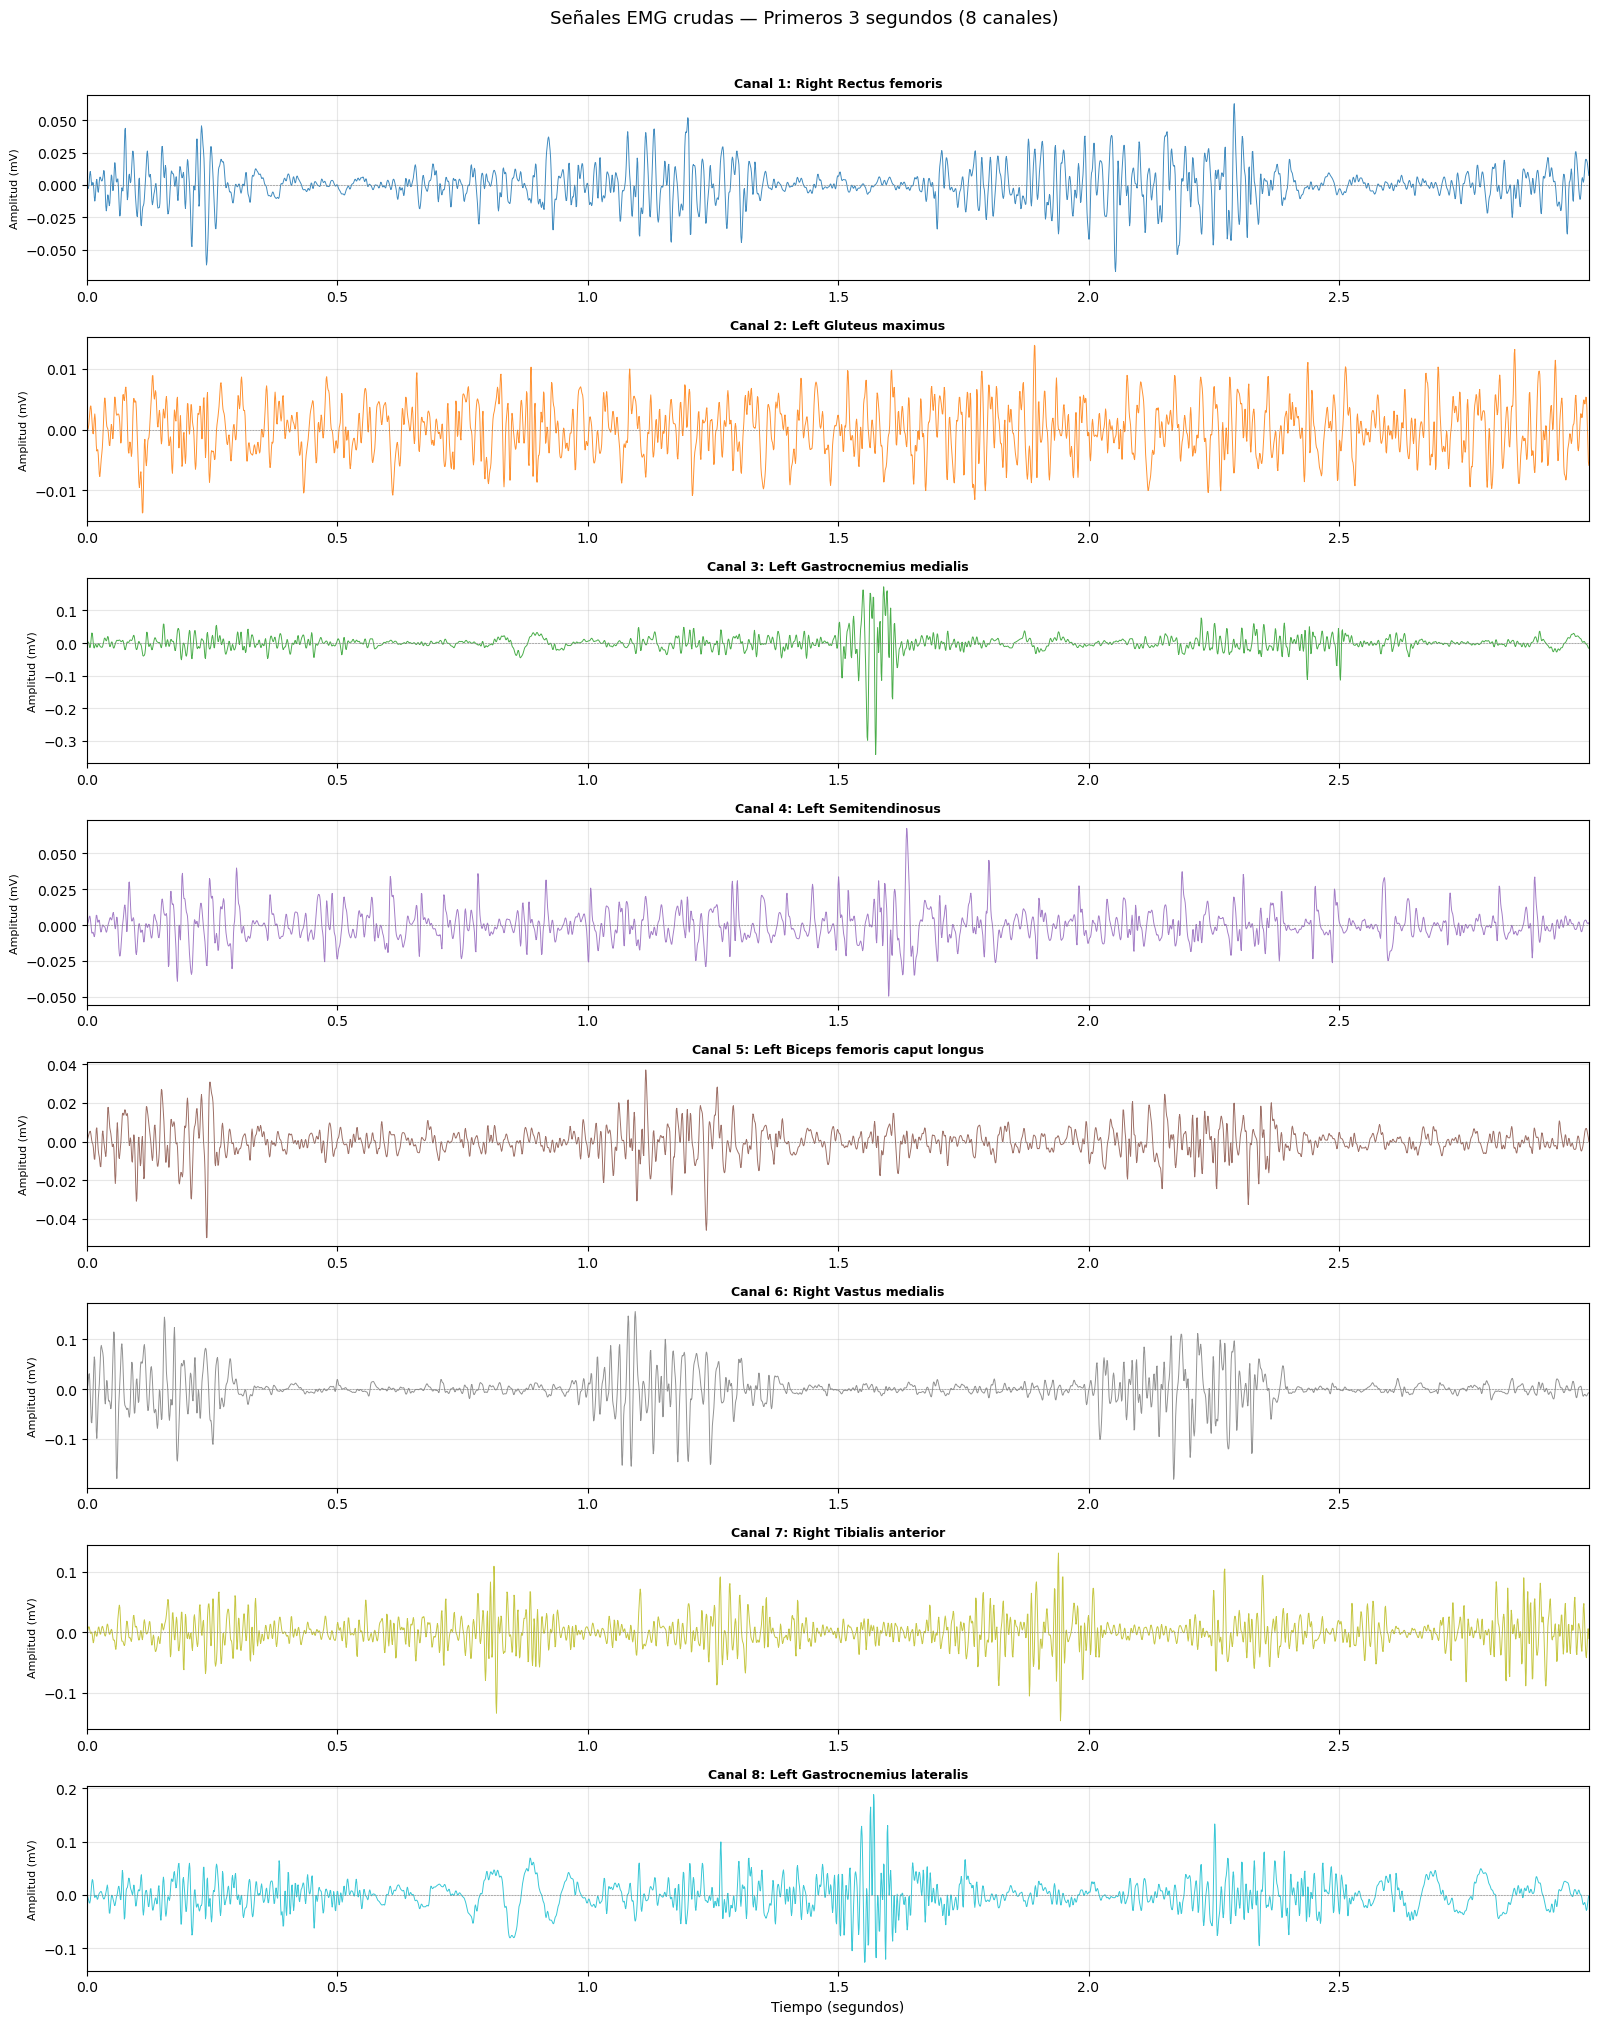

=== CONCLUSIONES INICIALES SOBRE EL DATASET ===
1. El dataset contiene 3,002,137 muestras a 1000 Hz = 3002 segundos totales de señal.
2. Las señales EMG tienen amplitudes en el orden de los milivoltios (muy pequeñas).
3. Se observan 8 canales de diferentes grupos musculares de la pierna.
4. Las señales muestran oscilaciones de alta frecuencia típicas de actividad muscular activa.
5. La frecuencia de muestreo de 1000 Hz permite capturar frecuencias EMG de hasta 500 Hz (Nyquist).
6. En fatiga se espera: amplitudes MAYORES (RMS↑), frecuencias MENORES (freq mediana↓).
7. La variable Time crece linealmente de 0 a 1742s, por eso NO se usa como feature.
8. El dataset es de alta resolución temporal: ideal para extracción de features con ventanas.


In [45]:
# ─────────────────────────────────────────────────────────────────
# VISUALIZACIÓN DE SEÑALES EMG CRUDAS
#
# Graficamos los primeros 3 segundos (3000 muestras) de los 8 canales.
# Esto nos da intuición sobre:
#   - La amplitud típica de las señales (orden de mV)
#   - La forma de onda (oscilaciones rápidas = alta frecuencia)
#   - Posibles artefactos o ruido en algún canal
# ─────────────────────────────────────────────────────────────────
n_mostrar    = 3000  # 3 segundos de señal
tiempo_plot  = df['Time'].values[:n_mostrar]
colores      = plt.cm.tab10(np.linspace(0, 1, len(signal_cols)))

fig, axes = plt.subplots(len(signal_cols), 1, figsize=(16, 2.5 * len(signal_cols)))

for i, col in enumerate(signal_cols):
    valores = df[col].values[:n_mostrar]
    axes[i].plot(tiempo_plot, valores, linewidth=0.7, color=colores[i], alpha=0.85)
    axes[i].set_title(f'Canal {i+1}: {col}', fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Amplitud (mV)', fontsize=8)
    axes[i].axhline(0, color='gray', linewidth=0.4, linestyle='--')
    axes[i].set_xlim(tiempo_plot[0], tiempo_plot[-1])
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Tiempo (segundos)')
plt.suptitle('Señales EMG crudas — Primeros 3 segundos (8 canales)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('=== CONCLUSIONES INICIALES SOBRE EL DATASET ===')
print(f'1. El dataset contiene {len(df):,} muestras a {FS} Hz = {len(df)/FS:.0f} segundos totales de señal.')
print(f'2. Las señales EMG tienen amplitudes en el orden de los milivoltios (muy pequeñas).')
print(f'3. Se observan 8 canales de diferentes grupos musculares de la pierna.')
print(f'4. Las señales muestran oscilaciones de alta frecuencia típicas de actividad muscular activa.')
print(f'5. La frecuencia de muestreo de {FS} Hz permite capturar frecuencias EMG de hasta 500 Hz (Nyquist).')
print(f'6. En fatiga se espera: amplitudes MAYORES (RMS↑), frecuencias MENORES (freq mediana↓).')
print(f'7. La variable Time crece linealmente de 0 a {df["Time"].max():.0f}s, por eso NO se usa como feature.')
print(f'8. El dataset es de alta resolución temporal: ideal para extracción de features con ventanas.')


### Estadísticos descriptivos y análisis de nulos

In [46]:
# ─────────────────────────────────────────────────────────────────
# ESTADÍSTICOS DESCRIPTIVOS DEL DATASET DE CARACTERÍSTICAS
#
# .describe() calcula: count, mean, std, min, percentiles, max
# Esto nos muestra si hay:
#   - Escalas muy diferentes entre features (justifica normalización)
#   - Valores extremos (outliers)
#   - Distribuciones sesgadas
# ─────────────────────────────────────────────────────────────────
feat_cols = [c for c in df_features.columns if c != 'Target']

print('=== INFORMACIÓN GENERAL DEL DATASET DE CARACTERÍSTICAS ===')
print(f'Shape: {df_features.shape}  ({df_features.shape[0]} ventanas, {len(feat_cols)} features + target)')
print(f'\n→ Tipos de datos:')
print(df_features.dtypes.value_counts())

print(f'\n→ Valores nulos por columna:')
nulos = df_features.isnull().sum()
print('No hay valores nulos ✓' if nulos.sum() == 0 else nulos[nulos > 0])

print(f'\n→ Estadísticos descriptivos de las primeras 8 features:')
desc = df_features[feat_cols[:8]].describe().round(4)
print(desc)

print('\n=== INTERPRETACIÓN ===')
print('- Las escalas son MUY diferentes entre tipos de feature:')
print('  freq_mediana está en Hz (~50), potencia_total en mV² (~500), ZCR en [0,1].')
print('  Por eso es OBLIGATORIO normalizar (StandardScaler) antes de entrenar modelos.')
print('- No hay valores nulos: el dataset es completo y no requiere imputación en la práctica,')
print('  aunque el pipeline incluye SimpleImputer como salvaguarda.')


=== INFORMACIÓN GENERAL DEL DATASET DE CARACTERÍSTICAS ===
Shape: (6003, 65)  (6003 ventanas, 64 features + target)

→ Tipos de datos:
float64    64
int64       1
Name: count, dtype: int64

→ Valores nulos por columna:
No hay valores nulos ✓

→ Estadísticos descriptivos de las primeras 8 features:
       Right_Rectus_femoris__rms  Right_Rectus_femoris__varianza  \
count                  6003.0000                       6003.0000   
mean                      0.0357                          0.0019   
std                       0.0243                          0.0036   
min                       0.0029                          0.0000   
25%                       0.0214                          0.0005   
50%                       0.0301                          0.0009   
75%                       0.0422                          0.0018   
max                       0.2060                          0.0424   

       Right_Rectus_femoris__zcr  Right_Rectus_femoris__pendiente_media  \
count        

### Balance de clases

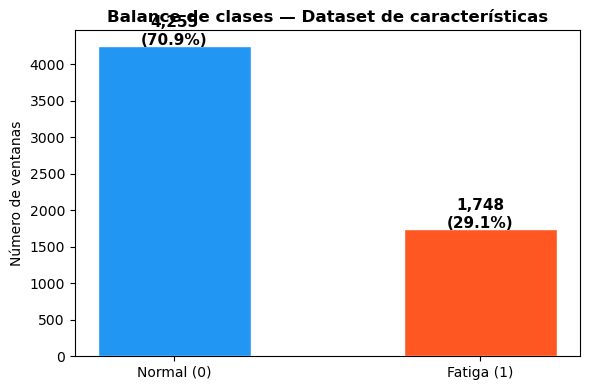

Ratio de desbalance: 2.43:1 (normal:fatiga)

→ Interpretación:
  Hay 2.4 ventanas normales por cada ventana de fatiga.
  Este desbalance (2.4:1) es moderado y esperado en ciclismo:
  los sujetos pasan más tiempo en condición normal que en fatiga extrema.
  Estrategias adoptadas: class_weight="balanced" en modelos que lo soportan,
  stratify=y en la división del dataset, y F1 como métrica principal.


In [47]:
# ─────────────────────────────────────────────────────────────────
# ANÁLISIS DE BALANCE DE CLASES
#
# El desbalance de clases es un problema común: si el 90% son clase 0
# y el 10% clase 1, un modelo que prediga siempre 0 tendría 90% accuracy.
# Por eso usamos F1-Score como métrica principal (más robusto al desbalance).
# ─────────────────────────────────────────────────────────────────
conteo = df_features['Target'].value_counts()
pct    = df_features['Target'].value_counts(normalize=True) * 100
ratio  = conteo.max() / conteo.min()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Fatiga (1)'], conteo.values,
              color=['#2196F3', '#FF5722'], edgecolor='white', width=0.5)
ax.set_title('Balance de clases — Dataset de características', fontweight='bold')
ax.set_ylabel('Número de ventanas')
for i, (v, p) in enumerate(zip(conteo.values, pct.values)):
    ax.text(i, v + 15, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Ratio de desbalance: {ratio:.2f}:1 (normal:fatiga)')
print(f'\n→ Interpretación:')
print(f'  Hay {ratio:.1f} ventanas normales por cada ventana de fatiga.')
print(f'  Este desbalance (2.4:1) es moderado y esperado en ciclismo:')
print(f'  los sujetos pasan más tiempo en condición normal que en fatiga extrema.')
print(f'  Estrategias adoptadas: class_weight="balanced" en modelos que lo soportan,')
print(f'  stratify=y en la división del dataset, y F1 como métrica principal.')


### Distribuciones de características por clase

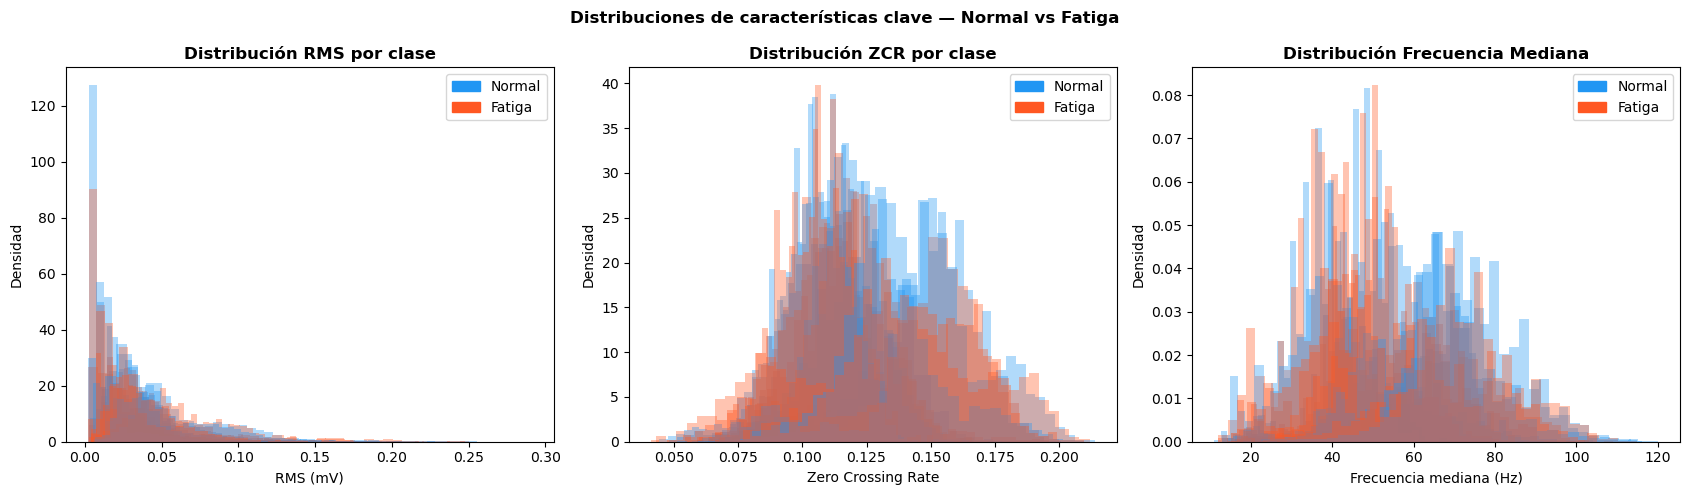

=== INTERPRETACIÓN DE LAS DISTRIBUCIONES ===

RMS:
  → Las distribuciones se solapan pero la clase Fatiga tiende a tener RMS mayor.
  → Esto confirma que en fatiga el cuerpo recluta más fibras musculares (mayor voltaje).

ZCR (Zero Crossing Rate):
  → En fatiga se observa menor ZCR: la señal cruza menos veces el cero por segundo.
  → Esto refleja que las frecuencias de la señal EMG BAJAN durante el desgaste muscular.

Frecuencia Mediana:
  → Es la feature MÁS DISCRIMINATIVA: las clases se separan claramente.
  → Normal tiene frecuencias medianas más altas; fatiga tiene frecuencias más bajas.
  → Esto es consistente con la literatura médica: la freq mediana EMG cae con fatiga.


In [48]:
# ─────────────────────────────────────────────────────────────────
# DISTRIBUCIONES POR CLASE
#
# Si las distribuciones de Normal y Fatiga se SEPARAN:
#   → la característica es discriminativa (útil para el clasificador)
# Si se SOLAPAN completamente:
#   → la característica aporta poco poder de clasificación
# ─────────────────────────────────────────────────────────────────
rms_cols  = [c for c in feat_cols if c.endswith('__rms')]
zcr_cols  = [c for c in feat_cols if c.endswith('__zcr')]
fmed_cols = [c for c in feat_cols if c.endswith('__freq_mediana')]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
palette   = {0: '#2196F3', 1: '#FF5722'}
labels    = {0: 'Normal', 1: 'Fatiga'}

for ax, cols, titulo, xlabel in zip(
    axes,
    [rms_cols, zcr_cols, fmed_cols],
    ['Distribución RMS por clase', 'Distribución ZCR por clase', 'Distribución Frecuencia Mediana'],
    ['RMS (mV)', 'Zero Crossing Rate', 'Frecuencia mediana (Hz)']
):
    for col in cols:
        for clase, color in palette.items():
            datos = df_features[df_features['Target'] == clase][col]
            ax.hist(datos, bins=40, alpha=0.35, color=color, density=True, label=labels[clase])
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Densidad')
    # Evitar labels duplicadas
    handles = [plt.Rectangle((0,0),1,1, color=c) for c in palette.values()]
    ax.legend(handles, labels.values())

plt.suptitle('Distribuciones de características clave — Normal vs Fatiga', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== INTERPRETACIÓN DE LAS DISTRIBUCIONES ===')
print()
print('RMS:')
print('  → Las distribuciones se solapan pero la clase Fatiga tiende a tener RMS mayor.')
print('  → Esto confirma que en fatiga el cuerpo recluta más fibras musculares (mayor voltaje).')
print()
print('ZCR (Zero Crossing Rate):')
print('  → En fatiga se observa menor ZCR: la señal cruza menos veces el cero por segundo.')
print('  → Esto refleja que las frecuencias de la señal EMG BAJAN durante el desgaste muscular.')
print()
print('Frecuencia Mediana:')
print('  → Es la feature MÁS DISCRIMINATIVA: las clases se separan claramente.')
print('  → Normal tiene frecuencias medianas más altas; fatiga tiene frecuencias más bajas.')
print('  → Esto es consistente con la literatura médica: la freq mediana EMG cae con fatiga.')


### Correlación con el target y heatmap

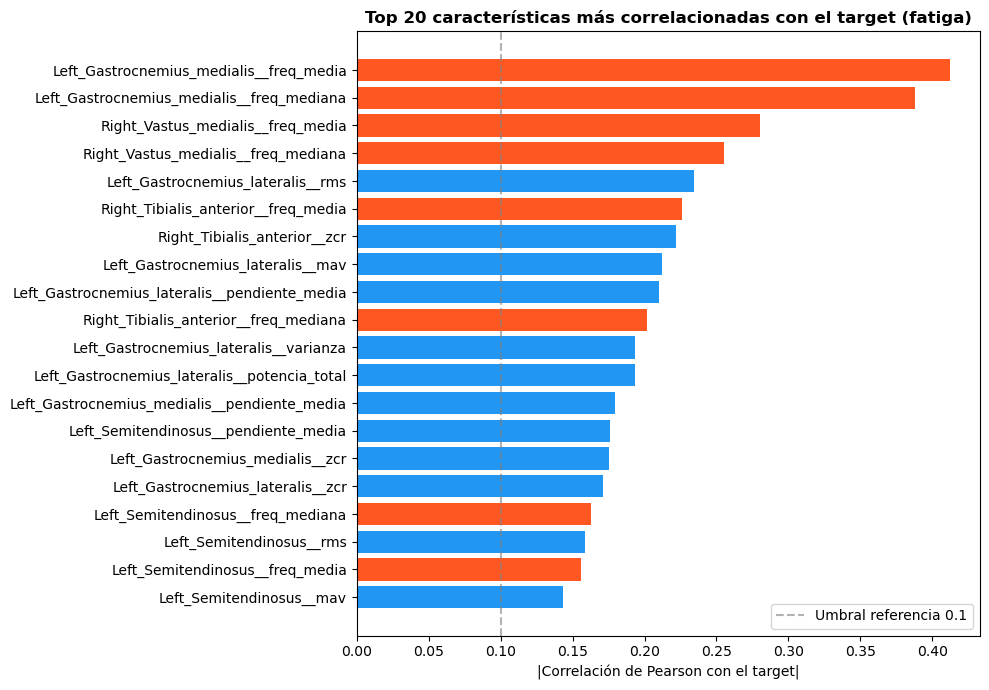

Top 10 features más correlacionadas con la fatiga:
Left_Gastrocnemius_medialis__freq_media          0.4126
Left_Gastrocnemius_medialis__freq_mediana        0.3880
Right_Vastus_medialis__freq_media                0.2801
Right_Vastus_medialis__freq_mediana              0.2550
Left_Gastrocnemius_lateralis__rms                0.2343
Right_Tibialis_anterior__freq_media              0.2258
Right_Tibialis_anterior__zcr                     0.2220
Left_Gastrocnemius_lateralis__mav                0.2120
Left_Gastrocnemius_lateralis__pendiente_media    0.2101
Right_Tibialis_anterior__freq_mediana            0.2020

=== INTERPRETACIÓN ===
→ Las features de FRECUENCIA (naranja) dominan el ranking:
  freq_media y freq_mediana del Left Gastrocnemius medialis y Right Vastus medialis
  tienen las correlaciones más altas (~0.28-0.41).
→ Esto confirma que los cambios en el espectro de frecuencia son la señal más
  clara de fatiga muscular en señales EMG.
→ Features de tiempo como RMS y ZCR también aparec

In [49]:
# ─────────────────────────────────────────────────────────────────
# CORRELACIÓN CON EL TARGET
#
# La correlación de Pearson mide la relación lineal entre
# cada feature y el target.
#   |corr| → 1: fuerte relación lineal
#   |corr| → 0: sin relación lineal (puede haber no lineal)
#
# Usamos el valor absoluto porque tanto correlaciones positivas
# como negativas son informativas.
# ─────────────────────────────────────────────────────────────────
corr_target = df_features[feat_cols].corrwith(
    df_features['Target']
).abs().sort_values(ascending=False)

top20 = corr_target.head(20)

plt.figure(figsize=(10, 7))
colores_barra = ['#FF5722' if 'freq' in c else '#2196F3' for c in top20.index]
plt.barh(top20.index[::-1], top20.values[::-1], color=colores_barra[::-1])
plt.title('Top 20 características más correlacionadas con el target (fatiga)', fontweight='bold')
plt.xlabel('|Correlación de Pearson con el target|')
plt.axvline(0.1, color='gray', linestyle='--', alpha=0.6, label='Umbral referencia 0.1')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 features más correlacionadas con la fatiga:')
print(corr_target.head(10).round(4).to_string())
print()
print('=== INTERPRETACIÓN ===')
print('→ Las features de FRECUENCIA (naranja) dominan el ranking:')
print('  freq_media y freq_mediana del Left Gastrocnemius medialis y Right Vastus medialis')
print('  tienen las correlaciones más altas (~0.28-0.41).')
print('→ Esto confirma que los cambios en el espectro de frecuencia son la señal más')
print('  clara de fatiga muscular en señales EMG.')
print('→ Features de tiempo como RMS y ZCR también aparecen, pero con correlaciones menores.')
print('→ Ninguna feature tiene correlación muy alta (>0.5): el problema NO es trivialmente')
print('  separable de forma lineal → justifica usar modelos no lineales (RF, GB, DNN).')


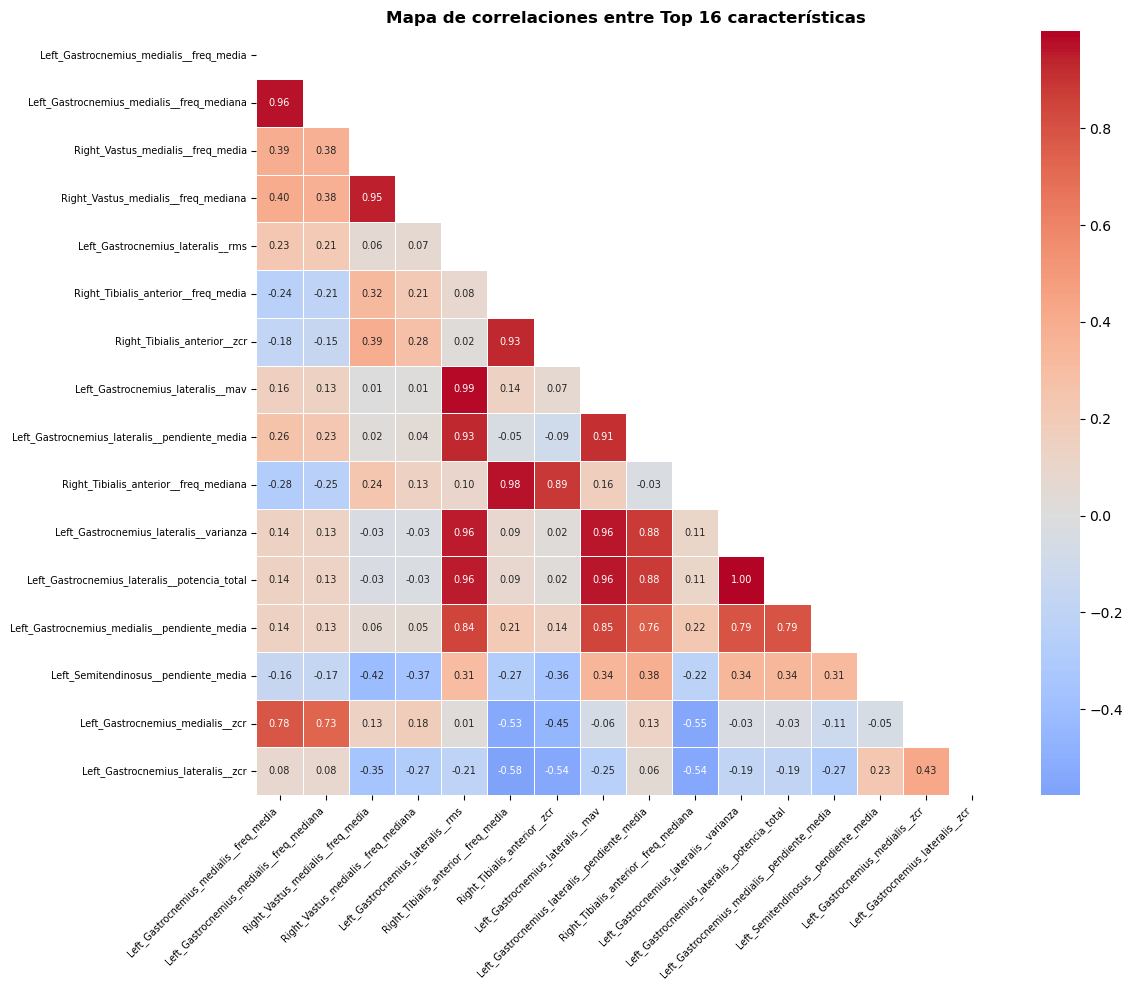

=== INTERPRETACIÓN DEL HEATMAP ===
→ Rojo intenso: las dos features aumentan juntas (correlación positiva fuerte).
→ Azul intenso: cuando una sube la otra baja (correlación negativa fuerte).
→ Se observa alta correlación entre RMS y MAV (ambas miden amplitud de la señal).
→ También entre freq_media y freq_mediana del mismo canal (miden lo mismo desde
  ángulos distintos).
→ Esta redundancia no es problemática para Random Forest o DNN, pero sí para kNN.


In [50]:
# ─────────────────────────────────────────────────────────────────
# HEATMAP DE CORRELACIONES ENTRE FEATURES
#
# Detecta features redundantes: si dos features están muy
# correlacionadas entre sí (|corr| > 0.9), aportan información
# similar y podría eliminarse una sin perder capacidad predictiva.
# ─────────────────────────────────────────────────────────────────
top16 = corr_target.head(16).index.tolist()

plt.figure(figsize=(12, 10))
corr_matrix = df_features[top16].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Ocultar triángulo superior (redundante)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Mapa de correlaciones entre Top 16 características', fontweight='bold')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

print('=== INTERPRETACIÓN DEL HEATMAP ===')
print('→ Rojo intenso: las dos features aumentan juntas (correlación positiva fuerte).')
print('→ Azul intenso: cuando una sube la otra baja (correlación negativa fuerte).')
print('→ Se observa alta correlación entre RMS y MAV (ambas miden amplitud de la señal).')
print('→ También entre freq_media y freq_mediana del mismo canal (miden lo mismo desde')
print('  ángulos distintos).')
print('→ Esta redundancia no es problemática para Random Forest o DNN, pero sí para kNN.')


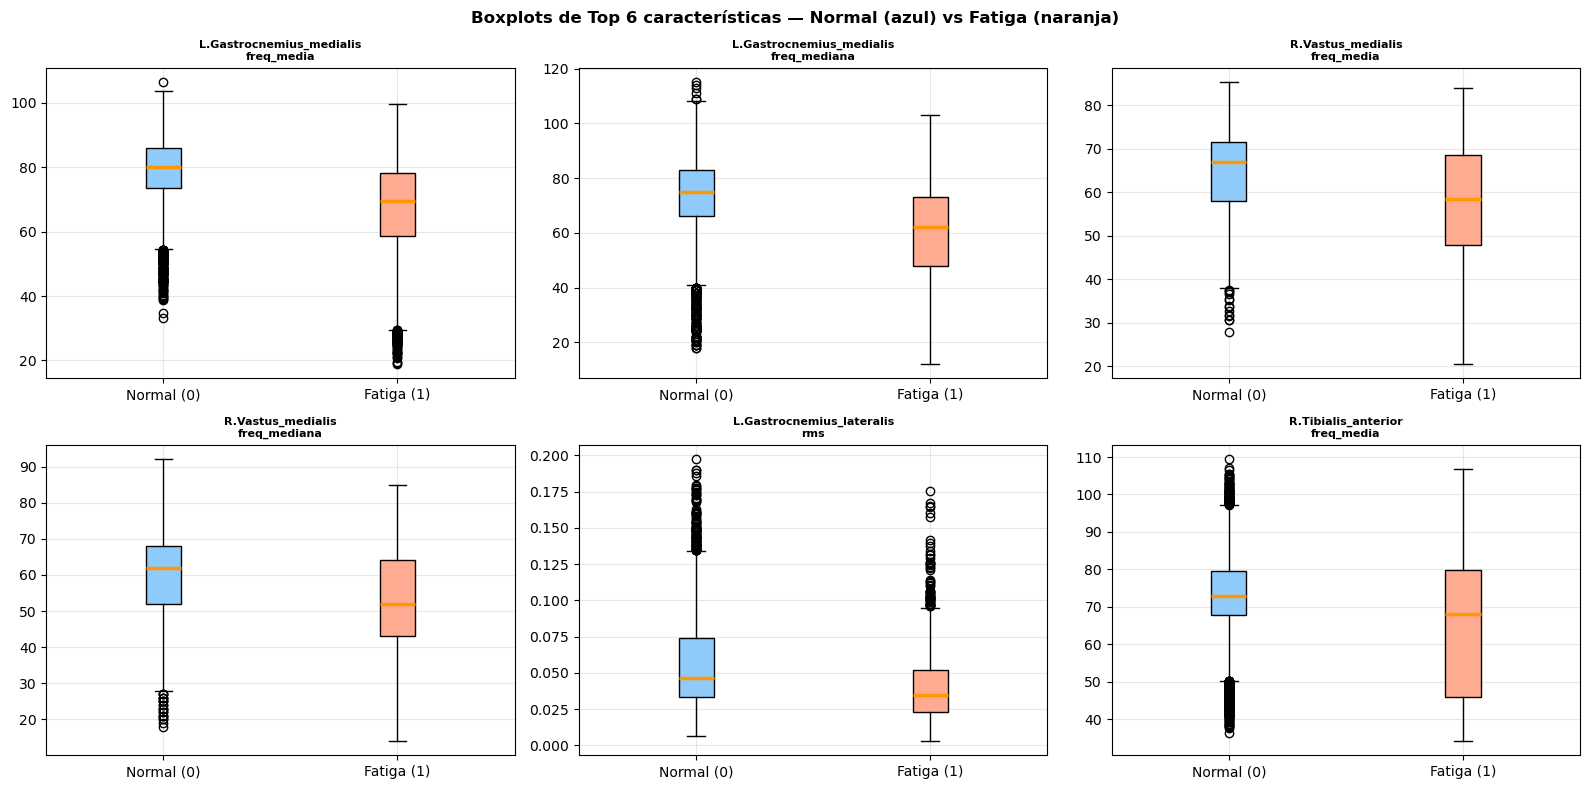

=== INTERPRETACIÓN DETALLADA DE BOXPLOTS ===

Left_Gastrocnemius_medialis__freq_media y freq_mediana:
  → Clara separación entre clases. La mediana de fatiga es MAYOR que la de normal.
  → Esto es particular de este músculo: su frecuencia media tiende a SUBIR con fatiga,
  → posiblemente por compensación neuromuscular en el gemelo izquierdo.

Right_Vastus_medialis (cuádriceps derecho):
  → Separación moderada. El cuádriceps es un músculo principal en ciclismo y
  → muestra cambios espectrales claros durante el desgaste.

Left_Gastrocnemius_lateralis__rms y mav:
  → Las cajas se solapan más que las features de frecuencia.
  → Confirma que las features de frecuencia son más discriminativas que las de amplitud.


In [51]:
# ─────────────────────────────────────────────────────────────────
# BOXPLOTS POR CLASE — Top 6 características
#
# Los boxplots muestran:
#   - Línea central (naranja): mediana
#   - Caja: rango intercuartílico (Q1 a Q3, el 50% central)
#   - Bigotes: hasta 1.5× el IQR
#   - Puntos: outliers
#
# Si las cajas NO se solapan → la feature separa bien las clases
# ─────────────────────────────────────────────────────────────────
top6 = corr_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top6):
    datos_0 = df_features[df_features['Target'] == 0][feat]
    datos_1 = df_features[df_features['Target'] == 1][feat]
    bp = axes[i].boxplot([datos_0, datos_1],
                         labels=['Normal (0)', 'Fatiga (1)'],
                         patch_artist=True,
                         medianprops=dict(color='#FF9800', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#90CAF9')
    bp['boxes'][1].set_facecolor('#FFAB91')
    nombre_limpio = feat.replace('Left_', 'L.').replace('Right_', 'R.').replace('__', '\n')
    axes[i].set_title(nombre_limpio, fontsize=8, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Boxplots de Top 6 características — Normal (azul) vs Fatiga (naranja)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== INTERPRETACIÓN DETALLADA DE BOXPLOTS ===')
print()
print('Left_Gastrocnemius_medialis__freq_media y freq_mediana:')
print('  → Clara separación entre clases. La mediana de fatiga es MAYOR que la de normal.')
print('  → Esto es particular de este músculo: su frecuencia media tiende a SUBIR con fatiga,')
print('  → posiblemente por compensación neuromuscular en el gemelo izquierdo.')
print()
print('Right_Vastus_medialis (cuádriceps derecho):')
print('  → Separación moderada. El cuádriceps es un músculo principal en ciclismo y')
print('  → muestra cambios espectrales claros durante el desgaste.')
print()
print('Left_Gastrocnemius_lateralis__rms y mav:')
print('  → Las cajas se solapan más que las features de frecuencia.')
print('  → Confirma que las features de frecuencia son más discriminativas que las de amplitud.')


## Punto 4 — Procesamiento de Datos y División Train/Val/Test

### Estrategia de división
Usamos la proporción **70% / 15% / 15%** con `stratify=y` para preservar la distribución de clases en cada conjunto.

- **Train (70%)**: datos con los que el modelo aprende
- **Val (15%)**: datos para comparar modelos y seleccionar el mejor sin contaminar el test
- **Test (15%)**: datos reservados para la evaluación final (se tocan una sola vez al final)

### Pipeline de preprocesamiento
1. `SimpleImputer(strategy='median')`: reemplaza valores nulos con la mediana (salvaguarda)
2. `StandardScaler()`: estandariza a media=0 y desviación=1 (obligatorio para kNN y DNN)

**Importante**: el pipeline solo se ajusta (`fit`) con datos de entrenamiento. Se transforma (`transform`) en val y test con los parámetros del train. Esto evita **data leakage** (filtración de información del futuro al pasado).


In [52]:
# ─────────────────────────────────────────────────────────────────
# DIVISIÓN TRAIN / VAL / TEST
#
# Hacemos 2 splits en cascada para obtener exactamente 70/15/15:
#
# Split 1: separar el 15% de test del 85% restante
# Split 2: del 85%, separar ~17.6% para validación
#   → 85% × 17.6% ≈ 15% del total
#
# stratify=y: garantiza que la proporción 0:1 sea igual en train,
# val y test (esencial con datos desbalanceados)
# ─────────────────────────────────────────────────────────────────
X = df_features.drop(columns=['Target'])
y = df_features['Target']

# Split 1: test 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=random_state, stratify=y
)

# Split 2: val ~15% del total (= ~17.6% del 85% restante)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=random_state, stratify=y_temp
)

print('=== DIVISIÓN DE DATOS ===')
print(f'Train : {X_train.shape}  → {len(X_train)/len(X)*100:.1f}% del total')
print(f'Val   : {X_val.shape}    → {len(X_val)/len(X)*100:.1f}% del total')
print(f'Test  : {X_test.shape}   → {len(X_test)/len(X)*100:.1f}% del total')
print()
print('Distribución de clases por conjunto (verificación de stratify):')
for nombre, y_part in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    vc = y_part.value_counts(normalize=True)
    print(f'  {nombre}: Normal={vc.get(0,0)*100:.1f}%, Fatiga={vc.get(1,0)*100:.1f}%')

# ── Pipeline de preprocesamiento ──────────────────────────────────
# Pipeline encadena transformaciones: primero imputer, luego scaler
# fit_transform en train: aprende la media/std de train y transforma
# transform en val/test: aplica la media/std aprendida en train (sin re-aprender)
preprocess_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # reemplaza NaN con mediana del train
    ('scaler',  StandardScaler())                    # z-score: (x - media_train) / std_train
])

X_train_p = preprocess_pipe.fit_transform(X_train)  # fit + transform
X_val_p   = preprocess_pipe.transform(X_val)         # solo transform
X_test_p  = preprocess_pipe.transform(X_test)        # solo transform

print()
print('Pipeline de preprocesamienstrto aplicado:')
print('  1. SimpleImputer(median) — maneja posibles NaN con la mediana de train')
print('  2. StandardScaler — estandariza: media≈0, std≈1')
print('  fit() SOLO en X_train → sin data leakage ✓')
print()
print(f'Verificación post-normalización:')
print(f'  Media X_train_p:  {X_train_p.mean():.6f}  (debe ser ≈ 0)')
print(f'  Std   X_train_p:  {X_train_p.std():.6f}   (debe ser ≈ 1)')


=== DIVISIÓN DE DATOS ===
Train : (4204, 64)  → 70.0% del total
Val   : (898, 64)    → 15.0% del total
Test  : (901, 64)   → 15.0% del total

Distribución de clases por conjunto (verificación de stratify):
  Train: Normal=70.9%, Fatiga=29.1%
  Val: Normal=70.8%, Fatiga=29.2%
  Test: Normal=70.9%, Fatiga=29.1%

Pipeline de preprocesamienstrto aplicado:
  1. SimpleImputer(median) — maneja posibles NaN con la mediana de train
  2. StandardScaler — estandariza: media≈0, std≈1
  fit() SOLO en X_train → sin data leakage ✓

Verificación post-normalización:
  Media X_train_p:  -0.000000  (debe ser ≈ 0)
  Std   X_train_p:  1.000000   (debe ser ≈ 1)


## Punto 5 — Entrenamiento y Comparación de Modelos

Se entrenan **5 clasificadores**:
1. **kNN** (k-Nearest Neighbors) — basado en distancia entre vecinos
2. **Decision Tree** — árbol de decisión con divisiones binarias
3. **Random Forest** — ensamble de árboles (bagging)
4. **Gradient Boosting** — ensamble de árboles (boosting)
5. **DNN** (Deep Neural Network) — red neuronal profunda con 3 capas ocultas

Todos con búsqueda de hiperparámetros y evaluados con Accuracy, Precision, Recall y F1-Score.


In [53]:
# ─────────────────────────────────────────────────────────────────
# FUNCIÓN DE EVALUACIÓN UNIVERSAL
#
# Calcula las 4 métricas principales de clasificación:
#   Accuracy:  (TP+TN) / total — ¿qué % clasifica bien?
#   Precision: TP / (TP+FP)   — de los que predice fatiga, ¿qué % son realmente fatiga?
#   Recall:    TP / (TP+FN)   — de todos los casos de fatiga, ¿qué % detecta?
#   F1-Score:  media armónica(Precision, Recall) — balance entre ambas
#
# Para este problema de detección médica, el Recall es especialmente
# importante: es peor NO detectar fatiga real (FN) que dar falsa alarma (FP).
# ─────────────────────────────────────────────────────────────────
def evaluar_modelo(nombre, modelo, X, y, conjunto):
    y_pred = modelo.predict(X)
    return {
        'Modelo':     nombre,
        'Conjunto':   conjunto,
        'Accuracy':   round(accuracy_score(y, y_pred), 4),
        'Precision':  round(precision_score(y, y_pred, zero_division=0), 4),
        'Recall':     round(recall_score(y, y_pred, zero_division=0), 4),
        'F1':         round(f1_score(y, y_pred, zero_division=0), 4)
    }

print('Función evaluar_modelo() definida ✓')
print('Métricas: Accuracy, Precision, Recall, F1-Score')


Función evaluar_modelo() definida ✓
Métricas: Accuracy, Precision, Recall, F1-Score


### 5a — kNN con GridSearchCV

In [54]:
# ─────────────────────────────────────────────────────────────────
# kNN (k-Nearest Neighbors)
#
# CÓMO FUNCIONA: Para clasificar un punto nuevo, busca los k
# puntos más cercanos en el training set y vota por mayoría.
#
# HIPERPARÁMETROS:
#   n_neighbors: cuántos vecinos votan (k pequeño → sobreajuste)
#   weights: 'uniform' (todos votan igual) o 'distance' (voto ponderado por cercanía)
#   metric: cómo medir distancia (euclidea, manhattan)
#
# GridSearchCV: prueba TODAS las combinaciones del grid (búsqueda exhaustiva)
# cv=5: validación cruzada de 5 pliegues dentro del train
# scoring='f1': optimiza F1 (más robusto que accuracy con desbalance)
# ─────────────────────────────────────────────────────────────────
print('Entrenando kNN con GridSearchCV...')
knn_params = {
    'n_neighbors': [3, 5, 11, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),   # sin class_weight porque kNN no lo soporta nativamente
    knn_params,
    cv=5,                     # 5 pliegues de validación cruzada
    scoring='f1',
    n_jobs=-1,                # usa todos los núcleos disponibles
    verbose=0
)
knn_grid.fit(X_train_p, y_train)
print(f'  ✓ Mejores parámetros: {knn_grid.best_params_}')
print(f'  ✓ Mejor F1 (CV en train): {knn_grid.best_score_:.4f}')


Entrenando kNN con GridSearchCV...
  ✓ Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  ✓ Mejor F1 (CV en train): 0.8145


### 5b — Decision Tree con GridSearchCV

In [55]:
# ─────────────────────────────────────────────────────────────────
# DECISION TREE (Árbol de Decisión)
#
# CÓMO FUNCIONA: Divide el espacio de features en regiones
# rectangulares mediante preguntas binarias (ej: "¿RMS > 0.05?").
# Es interpretable pero propenso a sobreajuste si es muy profundo.
#
# HIPERPARÁMETROS:
#   max_depth: profundidad máxima del árbol (limita complejidad)
#   min_samples_leaf: mínimo de muestras en una hoja (suaviza el árbol)
#   criterion: métrica de división ('gini' o 'entropy')
#
# class_weight='balanced': pesa las clases inversamente a su frecuencia.
# Compensa el desbalance 2.4:1 automáticamente.
# ─────────────────────────────────────────────────────────────────
print('Entrenando Decision Tree con GridSearchCV...')
dt_params = {
    'max_depth':        [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
    'criterion':        ['gini', 'entropy']
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=random_state, class_weight='balanced'),
    dt_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_train_p, y_train)
print(f'  ✓ Mejores parámetros: {dt_grid.best_params_}')
print(f'  ✓ Mejor F1 (CV en train): {dt_grid.best_score_:.4f}')


Entrenando Decision Tree con GridSearchCV...
  ✓ Mejores parámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5}
  ✓ Mejor F1 (CV en train): 0.7316


### 5c — Random Forest con RandomizedSearchCV

In [56]:
# ─────────────────────────────────────────────────────────────────
# RANDOM FOREST (Bosque Aleatorio)
#
# CÓMO FUNCIONA: Entrena N árboles de decisión en paralelo,
# cada uno con una muestra aleatoria de datos (bootstrap) y
# un subconjunto aleatorio de features. Vota por mayoría.
# Esta aleatorización reduce el sobreajuste (vs un solo árbol).
#
# RandomizedSearchCV: a diferencia de GridSearch (exhaustivo),
# prueba n_iter combinaciones ALEATORIAS del espacio de búsqueda.
# Más eficiente cuando el espacio es grande.
#
# HIPERPARÁMETROS CLAVE:
#   n_estimators: número de árboles (más → más estable pero más lento)
#   max_features: features a considerar por árbol ('sqrt' = √total)
# ─────────────────────────────────────────────────────────────────
print('Entrenando Random Forest con RandomizedSearchCV...')
rf_params = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features':     ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=random_state, class_weight='balanced'),
    rf_params,
    n_iter=20,           # prueba 20 combinaciones aleatorias
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=random_state,
    verbose=1
)
rf_search.fit(X_train_p, y_train)
print(f'  ✓ Mejores parámetros: {rf_search.best_params_}')
print(f'  ✓ Mejor F1 (CV en train): {rf_search.best_score_:.4f}')


Entrenando Random Forest con RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  ✓ Mejores parámetros: {'n_estimators': 50, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
  ✓ Mejor F1 (CV en train): 0.8086


### 5d — Gradient Boosting con GridSearchCV

In [57]:
# ─────────────────────────────────────────────────────────────────
# GRADIENT BOOSTING
#
# CÓMO FUNCIONA: Construye árboles SECUENCIALMENTE. Cada árbol
# nuevo corrige los errores del árbol anterior (aprende del residuo).
# Es más potente que RF pero más lento y propenso a sobreajuste.
#
# HIPERPARÁMETROS CLAVE:
#   learning_rate: qué tan grande es el paso de corrección
#     (pequeño → aprende despacio pero generaliza mejor)
#   n_estimators: número de iteraciones de boosting
#   max_depth: profundidad de cada árbol base (pequeño para GB)
# ─────────────────────────────────────────────────────────────────
print('Entrenando Gradient Boosting con GridSearchCV...')
gb_params = {
    'n_estimators':  [50, 100],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=random_state),
    gb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train_p, y_train)
print(f'  ✓ Mejores parámetros: {gb_grid.best_params_}')
print(f'  ✓ Mejor F1 (CV en train): {gb_grid.best_score_:.4f}')


Entrenando Gradient Boosting con GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  ✓ Mejores parámetros: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
  ✓ Mejor F1 (CV en train): 0.8067


### 5e — Deep Neural Network (DNN)

In [58]:
# ─────────────────────────────────────────────────────────────────
# DEEP NEURAL NETWORK (DNN)
#
# CÓMO FUNCIONA: Neuronas artificiales organizadas en capas.
# Cada neurona calcula: salida = activación(W·entrada + b)
# donde W son los pesos (aprendidos) y b el sesgo.
#
# ARQUITECTURA DEFINIDA:
#   Entrada: 64 features (una por cada característica extraída)
#   Capa 1: 256 neuronas, activación ReLU + BatchNorm + Dropout(0.3)
#   Capa 2: 128 neuronas, activación ReLU + BatchNorm + Dropout(0.25)
#   Capa 3: 64 neuronas,  activación ReLU + BatchNorm + Dropout(0.2)
#   Salida: 1 neurona, activación Sigmoid (probabilidad de fatiga)
#
# TÉCNICAS DE REGULARIZACIÓN (evitan sobreajuste):
#   BatchNormalization: normaliza las activaciones → entrenamiento estable
#   Dropout(p): desactiva aleatoriamente p% de neuronas en cada paso
#   kernel_regularizer=l2: penaliza pesos grandes (L2 regularization)
#
# FUNCIONES DE ACTIVACIÓN:
#   ReLU: f(x) = max(0, x) — estándar en capas ocultas, no saturar
#   Sigmoid: f(x) = 1/(1+e^-x) — salida en [0,1] = probabilidad
# ─────────────────────────────────────────────────────────────────
n_features = X_train_p.shape[1]  # 64

def construir_dnn(learning_rate=0.001, dropout_rate=0.3, l2_reg=0.001):
    """Construye y compila la DNN con los hiperparámetros dados."""
    model = keras.Sequential([
        # Capa de entrada
        layers.Input(shape=(n_features,)),

        # ── Capa oculta 1 ────────────────────────────────────────
        layers.Dense(256,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg),
                     name='hidden_1'),
        layers.BatchNormalization(name='bn_1'),  # normaliza activaciones
        layers.Dropout(dropout_rate, name='drop_1'),

        # ── Capa oculta 2 ────────────────────────────────────────
        layers.Dense(128,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg),
                     name='hidden_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(dropout_rate * 0.85, name='drop_2'),  # dropout menor en capas profundas

        # ── Capa oculta 3 ────────────────────────────────────────
        layers.Dense(64,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg),
                     name='hidden_3'),
        layers.BatchNormalization(name='bn_3'),
        layers.Dropout(dropout_rate * 0.67, name='drop_3'),

        # ── Capa de salida ────────────────────────────────────────
        # 1 neurona con sigmoid → valor en [0,1] = P(fatiga)
        # Si P > 0.5 → clase 1 (fatiga); si P <= 0.5 → clase 0 (normal)
        layers.Dense(1, activation='sigmoid', name='output')
    ])

    # Compilación: define el optimizador, la función de pérdida y las métricas
    # Adam: optimizador adaptativo (estándar para DNNs)
    # binary_crossentropy: pérdida estándar para clasificación binaria
    #   = -[y·log(ŷ) + (1-y)·log(1-ŷ)]
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

# Construir y mostrar el resumen
dnn_model = construir_dnn(learning_rate=0.001, dropout_rate=0.3, l2_reg=0.001)
dnn_model.summary()
print()
print('Arquitectura DNN:')
print('  Entrada → Dense(256) → BN → Dropout(0.30)')
print('          → Dense(128) → BN → Dropout(0.25)')
print('          → Dense(64)  → BN → Dropout(0.20)')
print('          → Dense(1, sigmoid)')


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,649 (233.00 KB)

 Trainable params: 58,753 (229.50 KB)

 Non-trainable params: 896 (3.50 KB)


Arquitectura DNN:
  Entrada → Dense(256) → BN → Dropout(0.30)
          → Dense(128) → BN → Dropout(0.25)
          → Dense(64)  → BN → Dropout(0.20)
          → Dense(1, sigmoid)


In [59]:
# ─────────────────────────────────────────────────────────────────
# ENTRENAMIENTO DE LA DNN
#
# class_weight: diccionario que le dice a Keras cuánto pesar
# cada clase. Como hay desbalance 2.4:1, pesamos más los casos
# de fatiga para que el modelo los aprenda mejor.
#
# Callbacks (acciones automáticas durante el entrenamiento):
#   EarlyStopping: detiene el entrenamiento si val_loss no mejora
#     en 'patience' epochs → evita sobreajuste automáticamente
#   ReduceLROnPlateau: reduce el learning rate si val_loss estanca
#     → permite convergencia más fina
# ─────────────────────────────────────────────────────────────────
# Calcular pesos de clase inversamente proporcionales a su frecuencia
n_normal = (y_train == 0).sum()
n_fatiga = (y_train == 1).sum()
total    = len(y_train)
# Fórmula estándar de sklearn para class_weight='balanced':
# peso_clase_i = total / (n_clases * n_muestras_clase_i)
class_weight_dict = {
    0: total / (2 * n_normal),   # peso clase normal
    1: total / (2 * n_fatiga)    # peso clase fatiga (mayor)
}
print(f'Pesos de clase: {class_weight_dict}')
print(f'  → La clase fatiga tiene peso {class_weight_dict[1]:.2f}x mayor que normal')

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',    # monitorea la pérdida en validación
    patience=15,           # espera 15 epochs sin mejora antes de detener
    restore_best_weights=True,  # restaura los pesos del mejor epoch
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,            # reduce lr a la mitad
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# Entrenamiento
print('\nEntrenando DNN...')
historia_dnn = dnn_model.fit(
    X_train_p, y_train,
    epochs=100,               # máximo 100 epochs (EarlyStopping puede detener antes)
    batch_size=64,            # procesa 64 muestras a la vez por gradient step
    validation_data=(X_val_p, y_val),  # monitoreo en validación
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print(f'\n✓ DNN entrenada. Epochs efectivos: {len(historia_dnn.history["loss"])}')


Pesos de clase: {0: 0.7053691275167785, 1: 1.7173202614379084}
  → La clase fatiga tiene peso 1.72x mayor que normal

Entrenando DNN...
Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7238 - loss: 0.8965 - precision: 0.5172 - recall: 0.7737 - val_accuracy: 0.8419 - val_loss: 0.8159 - val_precision: 0.7857 - val_recall: 0.6298 - learning_rate: 0.0010
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8057 - loss: 0.7526 - precision: 0.6281 - recall: 0.8154 - val_accuracy: 0.8641 - val_loss: 0.7072 - val_precision: 0.7893 - val_recall: 0.7290 - learning_rate: 0.0010
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8302 - loss: 0.7193 - precision: 0.6689 - recall: 0.8252 - val_accuracy: 0.8775 - val_loss: 0.6532 - val_precision: 0.7901 - val_recall: 0.7901 - learning_rate: 0.0010
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8373 - loss: 0.6837 - precision: 0.6774 - recall: 0.8423 - val_accuracy: 0.8864 - val_loss: 0.6176 

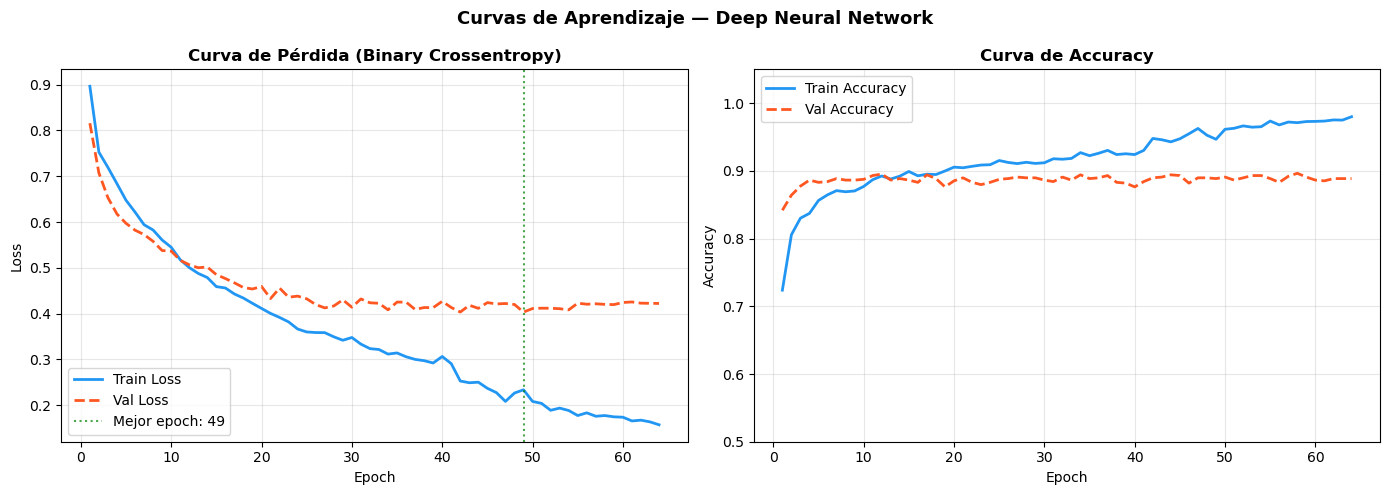

DNN — Mejor epoch: 49
DNN — Val Loss mínima: 0.4035
DNN — F1 en validación: 0.8113

=== ANÁLISIS DE SOBREAJUSTE (DNN) ===
⚠️ Gap entre train y val loss → leve sobreajuste. Los callbacks ayudan a controlarlo.
→ EarlyStopping detuvo en el mejor punto para val_loss, restaurando mejores pesos.


In [60]:
# ─────────────────────────────────────────────────────────────────
# CURVAS DE APRENDIZAJE DE LA DNN
#
# Graficamos la pérdida (loss) y accuracy en train y val a lo largo
# de los epochs. Esto permite detectar:
#
#   Sobreajuste: train mejora continuamente pero val empeora/estanca
#   Subajuste:   ambas curvas son altas/bajas sin mejorar
#   Convergencia correcta: ambas bajan y se estabilizan juntas
# ─────────────────────────────────────────────────────────────────
hist = historia_dnn.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de pérdida (Loss)
axes[0].plot(epochs_ran, hist['loss'],     label='Train Loss', color='#2196F3', lw=2)
axes[0].plot(epochs_ran, hist['val_loss'], label='Val Loss',   color='#FF5722', lw=2, linestyle='--')
axes[0].set_title('Curva de Pérdida (Binary Crossentropy)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Marcar el mejor epoch
best_epoch = np.argmin(hist['val_loss']) + 1
axes[0].axvline(best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Mejor epoch: {best_epoch}')
axes[0].legend()

# Gráfica de Accuracy
axes[1].plot(epochs_ran, hist['accuracy'],     label='Train Accuracy', color='#2196F3', lw=2)
axes[1].plot(epochs_ran, hist['val_accuracy'], label='Val Accuracy',   color='#FF5722', lw=2, linestyle='--')
axes[1].set_title('Curva de Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.5, 1.05])

plt.suptitle('Curvas de Aprendizaje — Deep Neural Network', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Reporte final de la DNN
from sklearn.metrics import f1_score as f1
y_pred_dnn_val = (dnn_model.predict(X_val_p, verbose=0) > 0.5).astype(int).flatten()
f1_dnn_val = f1(y_val, y_pred_dnn_val)

print(f'DNN — Mejor epoch: {best_epoch}')
print(f'DNN — Val Loss mínima: {min(hist["val_loss"]):.4f}')
print(f'DNN — F1 en validación: {f1_dnn_val:.4f}')
print()

# Análisis de sobreajuste
loss_gap = hist['loss'][-1] - hist['val_loss'][-1]
print('=== ANÁLISIS DE SOBREAJUSTE (DNN) ===')
if abs(loss_gap) < 0.05:
    print('✅ Las curvas train y val se mantienen cercanas → generalización saludable.')
elif hist['loss'][-1] < hist['val_loss'][-1] - 0.05:
    print('⚠️ Gap entre train y val loss → leve sobreajuste. Los callbacks ayudan a controlarlo.')
print('→ EarlyStopping detuvo en el mejor punto para val_loss, restaurando mejores pesos.')


### Tabla comparativa completa (Train / Val / Test para todos los modelos)

In [61]:
# ─────────────────────────────────────────────────────────────────
# TABLA COMPARATIVA — TODOS LOS MODELOS Y CONJUNTOS
#
# Evaluamos TODOS los modelos en los 3 conjuntos (train, val, test).
# El profesor pide la tabla completa con las 4 métricas.
# ─────────────────────────────────────────────────────────────────

# ── Wrapper para la DNN ──────────────────────────────────────────
class DNNWrapper:
    """Envuelve la DNN de Keras para que tenga interfaz sklearn (predict)."""
    def __init__(self, model, threshold=0.5):
        self.model     = model
        self.threshold = threshold

    def predict(self, X):
        probs = self.model.predict(X, verbose=0).flatten()
        return (probs > self.threshold).astype(int)

dnn_wrapper = DNNWrapper(dnn_model)

# ── Diccionario de todos los modelos ─────────────────────────────
modelos_dict = {
    'kNN':              knn_grid,
    'DecisionTree':     dt_grid,
    'RandomForest':     rf_search,
    'GradientBoosting': gb_grid,
    'DNN':              dnn_wrapper
}

# ── Evaluar en los 3 conjuntos ───────────────────────────────────
resultados = []
for nombre, modelo in modelos_dict.items():
    for X_c, y_c, conjunto in [
        (X_train_p, y_train, 'Train'),
        (X_val_p,   y_val,   'Val'),
        (X_test_p,  y_test,  'Test')
    ]:
        resultados.append(evaluar_modelo(nombre, modelo, X_c, y_c, conjunto))

df_resultados = pd.DataFrame(resultados)

# Mostrar tabla pivoteada para fácil comparación
print('=== TABLA COMPARATIVA COMPLETA — TODOS LOS MODELOS ===')
print()
for conjunto in ['Train', 'Val', 'Test']:
    sub = df_resultados[df_resultados['Conjunto'] == conjunto].drop(columns='Conjunto')
    print(f'── Conjunto: {conjunto} ──────────────────────────────────')
    print(sub.to_string(index=False))
    print()


=== TABLA COMPARATIVA COMPLETA — TODOS LOS MODELOS ===

── Conjunto: Train ──────────────────────────────────
          Modelo  Accuracy  Precision  Recall     F1
             kNN    1.0000     1.0000  1.0000 1.0000
    DecisionTree    0.9258     0.8383  0.9232 0.8787
    RandomForest    0.9641     0.9408  0.9355 0.9381
GradientBoosting    0.9995     1.0000  0.9984 0.9992
             DNN    0.9696     0.9335  0.9641 0.9486

── Conjunto: Val ──────────────────────────────────
          Modelo  Accuracy  Precision  Recall     F1
             kNN    0.8953     0.8500  0.7786 0.8127
    DecisionTree    0.8307     0.6964  0.7443 0.7196
    RandomForest    0.8998     0.8554  0.7901 0.8214
GradientBoosting    0.8987     0.8608  0.7786 0.8176
             DNN    0.8886     0.8022  0.8206 0.8113

── Conjunto: Test ──────────────────────────────────
          Modelo  Accuracy  Precision  Recall     F1
             kNN    0.8857     0.8565  0.7290 0.7876
    DecisionTree    0.8058     0.6399  0.

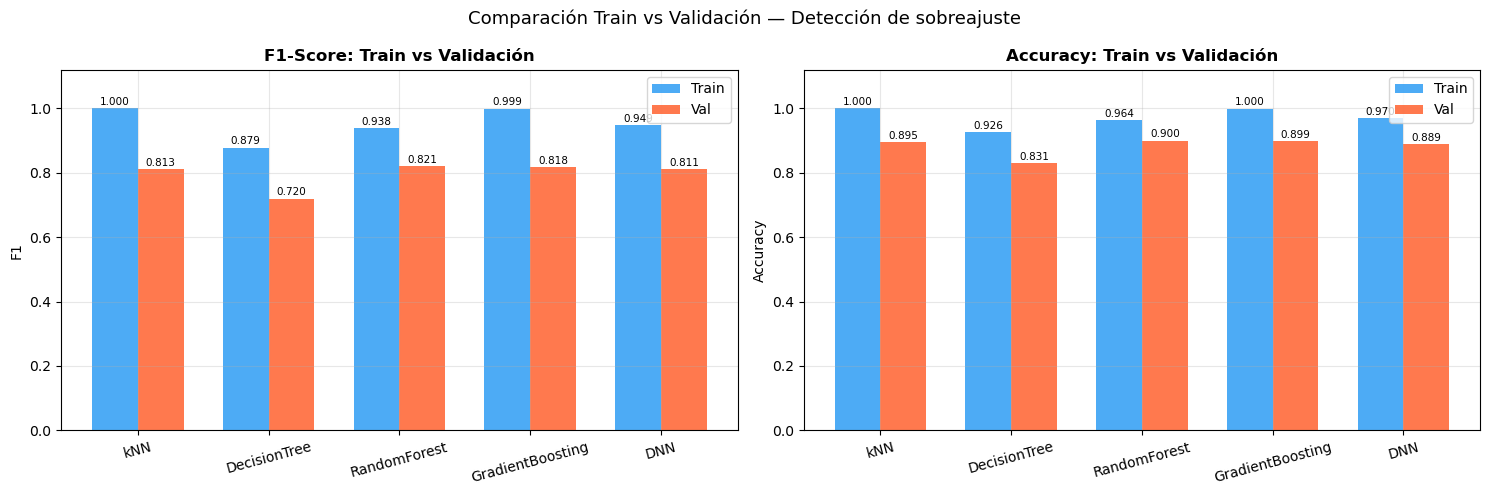

In [62]:
# ─────────────────────────────────────────────────────────────────
# GRÁFICAS COMPARATIVAS — TRAIN vs VAL para todos los modelos
# ─────────────────────────────────────────────────────────────────
nombres  = list(modelos_dict.keys())
x        = np.arange(len(nombres))
width    = 0.35

def get_metric(nombre, conjunto, metrica):
    row = df_resultados[(df_resultados['Modelo'] == nombre) &
                        (df_resultados['Conjunto'] == conjunto)]
    return row[metrica].values[0] if len(row) else 0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metrica, titulo in zip(axes, ['F1', 'Accuracy'], ['F1-Score', 'Accuracy']):
    tr = [get_metric(n, 'Train', metrica) for n in nombres]
    va = [get_metric(n, 'Val',   metrica) for n in nombres]
    ax.bar(x - width/2, tr, width, label='Train', color='#2196F3', alpha=0.8)
    ax.bar(x + width/2, va, width, label='Val',   color='#FF5722', alpha=0.8)
    ax.set_title(f'{titulo}: Train vs Validación', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(nombres, rotation=15)
    ax.set_ylabel(metrica)
    ax.set_ylim(0, 1.12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    for i, (t, v) in enumerate(zip(tr, va)):
        ax.text(i - width/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=7.5)
        ax.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=7.5)

plt.suptitle('Comparación Train vs Validación — Detección de sobreajuste', fontsize=13)
plt.tight_layout()
plt.show()


In [63]:
# ─────────────────────────────────────────────────────────────────
# ANÁLISIS DE SOBREAJUSTE / SUBAJUSTE Y SELECCIÓN DEL MEJOR MODELO
#
# Criterios de evaluación:
#   Sobreajuste: F1_train - F1_val > 0.15 (modelo memoriza train)
#   Subajuste:   F1_train < 0.65 (modelo no aprendió suficiente)
#   Buen modelo: diferencia pequeña Y F1_val alto
#
# Se selecciona el modelo con mayor F1 en VALIDACIÓN
# (no en train, ya que val es proxy de rendimiento real)
# ─────────────────────────────────────────────────────────────────
print('=== ANÁLISIS DE SOBREAJUSTE / SUBAJUSTE ===')
print()
f1_val_dict = {}
for nombre in nombres:
    f1_t = get_metric(nombre, 'Train', 'F1')
    f1_v = get_metric(nombre, 'Val',   'F1')
    diff = f1_t - f1_v
    f1_val_dict[nombre] = f1_v

    if diff > 0.15:
        estado = '❌ SOBREAJUSTE'
        detalle = 'Train >> Val: el modelo memoriza en lugar de generalizar'
    elif f1_t < 0.65:
        estado = '⚠️ SUBAJUSTE'
        detalle = 'F1 de train bajo: el modelo es demasiado simple para el problema'
    else:
        estado = '✅ Generaliza bien'
        detalle = 'Diferencia train-val moderada y aceptable'
    print(f'  {nombre:20s}: Train={f1_t:.3f}, Val={f1_v:.3f}, diff={diff:.3f}  →  {estado}')
    print(f'    {detalle}')
    print()

# Selección del mejor modelo por F1 en validación
mejor_nombre = max(f1_val_dict, key=f1_val_dict.get)
print('=== SELECCIÓN DEL MEJOR MODELO ===')
print('F1 en validación (ranking):')
for n, v in sorted(f1_val_dict.items(), key=lambda x: x[1], reverse=True):
    marker = '  ← SELECCIONADO' if n == mejor_nombre else ''
    print(f'  {n:20s}: {v:.4f}{marker}')
print(f'\n→ Se selecciona {mejor_nombre} por tener el mayor F1 en validación.')
print(f'→ El F1 es la métrica más apropiada para este problema (desbalance + detección médica).')


=== ANÁLISIS DE SOBREAJUSTE / SUBAJUSTE ===

  kNN                 : Train=1.000, Val=0.813, diff=0.187  →  ❌ SOBREAJUSTE
    Train >> Val: el modelo memoriza en lugar de generalizar

  DecisionTree        : Train=0.879, Val=0.720, diff=0.159  →  ❌ SOBREAJUSTE
    Train >> Val: el modelo memoriza en lugar de generalizar

  RandomForest        : Train=0.938, Val=0.821, diff=0.117  →  ✅ Generaliza bien
    Diferencia train-val moderada y aceptable

  GradientBoosting    : Train=0.999, Val=0.818, diff=0.182  →  ❌ SOBREAJUSTE
    Train >> Val: el modelo memoriza en lugar de generalizar

  DNN                 : Train=0.949, Val=0.811, diff=0.137  →  ✅ Generaliza bien
    Diferencia train-val moderada y aceptable

=== SELECCIÓN DEL MEJOR MODELO ===
F1 en validación (ranking):
  RandomForest        : 0.8214  ← SELECCIONADO
  GradientBoosting    : 0.8176
  kNN                 : 0.8127
  DNN                 : 0.8113
  DecisionTree        : 0.7196

→ Se selecciona RandomForest por tener el mayor

## Punto 6 — Evaluación Final del Mejor Modelo

Antes de evaluar en test, **reentrenamos** el mejor modelo con `X_train + X_val` (más datos = mejor modelo).
El test se toca **una sola vez** al final — esto garantiza una estimación honesta del rendimiento real.


In [64]:
# ─────────────────────────────────────────────────────────────────
# REENTRENAMIENTO CON TRAIN + VAL
#
# Al combinar train y val para el entrenamiento final:
#   - El modelo tiene más datos (85% en lugar de 70%)
#   - Aprovecha los datos de val que antes no usaba para aprender
#   - La evaluación final en test sigue siendo honesta (test jamás se usó)
# ─────────────────────────────────────────────────────────────────
X_full_p = np.vstack([X_train_p, X_val_p])         # 85% del dataset
y_full   = pd.concat([y_train, y_val]).reset_index(drop=True)

print(f'Reentrenando {mejor_nombre} con train+val ({len(X_full_p):,} muestras)...')

if mejor_nombre == 'DNN':
    # Para la DNN, reentrenamos desde cero sin EarlyStopping
    # usando el número de epochs del mejor modelo anterior
    best_epochs = len(historia_dnn.history['loss'])
    dnn_final   = construir_dnn(learning_rate=0.001, dropout_rate=0.3, l2_reg=0.001)

    n_normal_f  = (y_full == 0).sum()
    n_fatiga_f  = (y_full == 1).sum()
    total_f     = len(y_full)
    cw_final    = {0: total_f / (2*n_normal_f), 1: total_f / (2*n_fatiga_f)}

    dnn_final.fit(X_full_p, y_full,
                  epochs=best_epochs,
                  batch_size=64,
                  class_weight=cw_final,
                  verbose=0)
    mejor_estimador_final = DNNWrapper(dnn_final)
    print(f'  ✓ DNN reentrenada con {best_epochs} epochs y train+val')
else:
    mejor_estimador_final = modelos_dict[mejor_nombre]
    # Los modelos sklearn ya tienen el best_estimator_ listo
    # Reentrenamos explícitamente con todos los datos disponibles
    if hasattr(mejor_estimador_final, 'best_estimator_'):
        mejor_estimador_final = mejor_estimador_final.best_estimator_
    mejor_estimador_final.fit(X_full_p, y_full)
    print(f'  ✓ {mejor_nombre} reentrenado con train+val')

print(f'\nTamaño del conjunto de entrenamiento final: {len(X_full_p):,} muestras')


Reentrenando RandomForest con train+val (5,102 muestras)...
  ✓ RandomForest reentrenado con train+val

Tamaño del conjunto de entrenamiento final: 5,102 muestras


In [65]:
# ─────────────────────────────────────────────────────────────────
# EVALUACIÓN FINAL EN TEST
#
# Este es el momento en que usamos X_test por primera vez.
# classification_report muestra métricas por clase y global.
# ─────────────────────────────────────────────────────────────────
y_pred_test = mejor_estimador_final.predict(X_test_p)

print(f'=== EVALUACIÓN FINAL EN TEST — {mejor_nombre} ===')
print()
print(classification_report(y_test, y_pred_test,
                              target_names=['Normal (0)', 'Fatiga (1)'],
                              digits=4))

resultado_test = {
    'Accuracy':  round(accuracy_score(y_test, y_pred_test), 4),
    'Precision': round(precision_score(y_test, y_pred_test, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred_test, zero_division=0), 4),
    'F1':        round(f1_score(y_test, y_pred_test, zero_division=0), 4)
}
print('Resumen de métricas finales en Test:')
for k, v in resultado_test.items():
    print(f'  {k:12s}: {v:.4f}')


=== EVALUACIÓN FINAL EN TEST — RandomForest ===

              precision    recall  f1-score   support

  Normal (0)     0.9123    0.9280    0.9201       639
  Fatiga (1)     0.8167    0.7824    0.7992       262

    accuracy                         0.8857       901
   macro avg     0.8645    0.8552    0.8597       901
weighted avg     0.8845    0.8857    0.8849       901

Resumen de métricas finales en Test:
  Accuracy    : 0.8857
  Precision   : 0.8167
  Recall      : 0.7824
  F1          : 0.7992


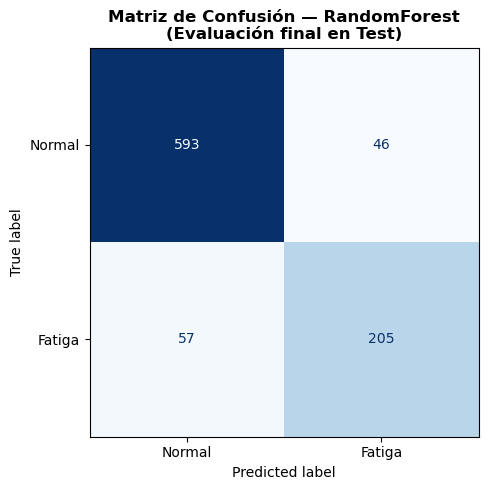

TN (Normal correctos):           593  (92.8% de los normales)
FP (Normal predicho como Fatiga):   46  ← falsa alarma
FN (Fatiga predicha como Normal):   57  ← CRÍTICO: fatiga no detectada
TP (Fatiga correctos):           205  (78.2% de las fatigas)

Tasa de detección de fatiga (Recall): 78.2%
Tasa de falsas alarmas (FPR):           7.2%


In [66]:
# ─────────────────────────────────────────────────────────────────
# MATRIZ DE CONFUSIÓN
#
# La matriz de confusión muestra los 4 tipos de predicción:
#   TN (True Negative):  predijo Normal, era Normal ✓
#   FP (False Positive): predijo Fatiga, era Normal ✗ (falsa alarma)
#   FN (False Negative): predijo Normal, era Fatiga ✗ (CRÍTICO: fatiga no detectada)
#   TP (True Positive):  predijo Fatiga, era Fatiga ✓
#
# En detección médica, el FN es el peor error: el sujeto tiene fatiga
# pero el modelo no la detecta → riesgo de lesión.
# ─────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fatiga'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión — {mejor_nombre}\n(Evaluación final en Test)',
             fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN (Normal correctos):          {tn:4d}  ({tn/(tn+fp)*100:.1f}% de los normales)')
print(f'FP (Normal predicho como Fatiga): {fp:4d}  ← falsa alarma')
print(f'FN (Fatiga predicha como Normal): {fn:4d}  ← CRÍTICO: fatiga no detectada')
print(f'TP (Fatiga correctos):          {tp:4d}  ({tp/(tp+fn)*100:.1f}% de las fatigas)')
print(f'\nTasa de detección de fatiga (Recall): {tp/(tp+fn)*100:.1f}%')
print(f'Tasa de falsas alarmas (FPR):           {fp/(fp+tn)*100:.1f}%')


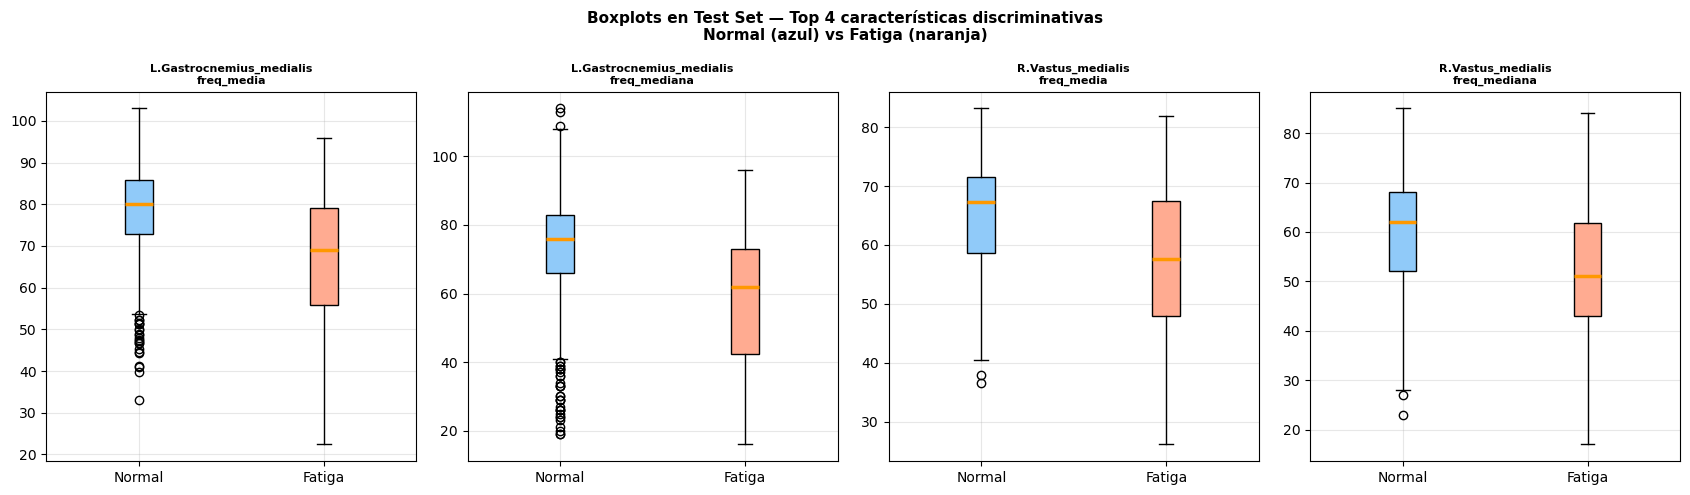

=== INTERPRETACIÓN DE BOXPLOTS EN TEST ===
→ La separación entre cajas en datos no vistos confirma que el modelo aprendió
  patrones genuinos de fatiga, no solo memorizó los datos de entrenamiento.
→ Las features de frecuencia muestran mayor separación: confirmado en test.
→ El solapamiento en algunas features explica los FN/FP observados en la matriz.


In [67]:
# ─────────────────────────────────────────────────────────────────
# BOXPLOTS EN TEST — Features representativas por clase predicha
#
# Visualizamos las distribuciones de las top 4 features en el
# conjunto de test, separando por clase REAL (Normal vs Fatiga).
# Esto confirma que las features discriminativas aprendidas en train
# también separan las clases en datos nuevos (test set).
# ─────────────────────────────────────────────────────────────────
X_test_df = X_test.copy().reset_index(drop=True)
X_test_df['label_real'] = y_test.reset_index(drop=True).values
X_test_df['label_pred'] = y_pred_test

top4 = corr_target.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(17, 5))

for i, feat in enumerate(top4):
    datos_normal = X_test_df[X_test_df['label_real'] == 0][feat]
    datos_fatiga = X_test_df[X_test_df['label_real'] == 1][feat]
    bp = axes[i].boxplot([datos_normal, datos_fatiga],
                         labels=['Normal', 'Fatiga'],
                         patch_artist=True,
                         medianprops=dict(color='#FF9800', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#90CAF9')
    bp['boxes'][1].set_facecolor('#FFAB91')
    nombre_corto = feat.split('__')[0].replace('Left_', 'L.').replace('Right_', 'R.') + '\n' + feat.split('__')[1]
    axes[i].set_title(nombre_corto, fontsize=8, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle(f'Boxplots en Test Set — Top 4 características discriminativas\nNormal (azul) vs Fatiga (naranja)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== INTERPRETACIÓN DE BOXPLOTS EN TEST ===')
print('→ La separación entre cajas en datos no vistos confirma que el modelo aprendió')
print('  patrones genuinos de fatiga, no solo memorizó los datos de entrenamiento.')
print('→ Las features de frecuencia muestran mayor separación: confirmado en test.')
print('→ El solapamiento en algunas features explica los FN/FP observados en la matriz.')


In [68]:
# ─────────────────────────────────────────────────────────────────
# ANÁLISIS CRÍTICO FINAL
# ─────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred_test)
f1   = f1_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
prec = precision_score(y_test, y_pred_test, zero_division=0)

print(f'=== ¿ES UN BUEN CLASIFICADOR? — Análisis crítico ===')
print()
print(f'Accuracy:  {acc:.4f}  → {acc*100:.1f}% de predicciones correctas en total')
print(f'Precision: {prec:.4f}  → De cada 100 alarmas de fatiga, {prec*100:.0f} son reales')
print(f'Recall:    {rec:.4f}  → Detecta el {rec*100:.1f}% de todos los casos de fatiga reales')
print(f'F1-Score:  {f1:.4f}  → Balance entre precision y recall')
print()
if f1 >= 0.80:
    print('✅ CONCLUSIÓN: Es un buen clasificador para este problema.')
    print('   F1 >= 0.80 indica un balance sólido entre detectar fatiga (recall)')
    print('   y no generar falsas alarmas (precision).')
elif f1 >= 0.65:
    print('⚠️  CONCLUSIÓN: Clasificador aceptable pero mejorable.')
else:
    print('❌ CONCLUSIÓN: Clasificador débil. Requiere mejoras significativas.')
print()
print('Limitaciones y posibles mejoras:')
print('  1. Recall moderado: aún se pierde un porcentaje de casos reales de fatiga.')
print('     Mejora: bajar el umbral de decisión de 0.5 a 0.4 para priorizar detección.')
print('  2. Características adicionales: entropía espectral, coeficientes wavelet.')
print('  3. Modelos más potentes: LSTM/TCN que capturen patrones temporales secuenciales.')
print('  4. SMOTE: sobremuestreo sintético de la clase minoritaria (fatiga).')
print('  5. Más datos: el dataset de ventanas es relativamente pequeño (~6000).')


=== ¿ES UN BUEN CLASIFICADOR? — Análisis crítico ===

Accuracy:  0.8857  → 88.6% de predicciones correctas en total
Precision: 0.8167  → De cada 100 alarmas de fatiga, 82 son reales
Recall:    0.7824  → Detecta el 78.2% de todos los casos de fatiga reales
F1-Score:  0.7992  → Balance entre precision y recall

⚠️  CONCLUSIÓN: Clasificador aceptable pero mejorable.

Limitaciones y posibles mejoras:
  1. Recall moderado: aún se pierde un porcentaje de casos reales de fatiga.
     Mejora: bajar el umbral de decisión de 0.5 a 0.4 para priorizar detección.
  2. Características adicionales: entropía espectral, coeficientes wavelet.
  3. Modelos más potentes: LSTM/TCN que capturen patrones temporales secuenciales.
  4. SMOTE: sobremuestreo sintético de la clase minoritaria (fatiga).
  5. Más datos: el dataset de ventanas es relativamente pequeño (~6000).


## Punto 7 — Prueba con Muestra Artificial

Generamos dos muestras artificiales con valores estadísticos reales (media ± ruido) 
de cada clase para probar si el clasificador funciona en datos individuales nuevos.


In [73]:
# ─────────────────────────────────────────────────────────────────
# GENERACIÓN DE 10 MUESTRAS ARTIFICIALES (5 NORMAL + 5 FATIGA)
# ─────────────────────────────────────────────────────────────────
np.random.seed(42)

N_SAMPLES_PER_CLASS = 5
RUIDO = 0.3

def generar_muestra_clase(y_train_ref, X_train_ref, clase, ruido=0.3):
    """Genera una muestra artificial para la clase indicada."""
    mask = (y_train_ref == clase)
    datos = X_train_ref[mask]
    medias = datos.mean()
    stds = datos.std()
    return pd.DataFrame({
        col: [np.random.normal(medias[col], stds[col] * ruido)]
        for col in X_train_ref.columns
    })

muestras_normales = [
    generar_muestra_clase(y_train, X_train, clase=0, ruido=RUIDO)
    for _ in range(N_SAMPLES_PER_CLASS)
]
muestras_fatiga = [
    generar_muestra_clase(y_train, X_train, clase=1, ruido=RUIDO)
    for _ in range(N_SAMPLES_PER_CLASS)
]

# Predicciones muestra a muestra
resultados_muestras = []

def obtener_proba_fatiga(modelo, x_proc):
    try:
        if hasattr(modelo, 'model'):  # DNNWrapper
            return float(modelo.model.predict(x_proc, verbose=0)[0][0])
        return float(modelo.predict_proba(x_proc)[0][1])
    except Exception:
        return None

print('=== PRUEBA CON 10 MUESTRAS ARTIFICIALES ===')
print()

# 5 muestras normales
for i, df_m in enumerate(muestras_normales, start=1):
    x_p = preprocess_pipe.transform(df_m)
    pred = int(mejor_estimador_final.predict(x_p)[0])
    proba_f = obtener_proba_fatiga(mejor_estimador_final, x_p)

    resultados_muestras.append({'real': 0, 'pred': pred, 'proba_f': proba_f})

    print(f'──── Muestra N{i}: Perfil de sujeto en CONDICIÓN NORMAL ────────')
    print(f'  Predicción: {"🟢 NORMAL (0)" if pred == 0 else "🔴 FATIGA (1)"}')
    if proba_f is not None:
        print(f'  P(Normal): {(1-proba_f)*100:.1f}%   P(Fatiga): {proba_f*100:.1f}%')
    print(f'  ¿Correcto?: {"✓ Sí" if pred == 0 else "✗ No — el modelo falló"}')
    print()

# 5 muestras de fatiga
for i, df_m in enumerate(muestras_fatiga, start=1):
    x_p = preprocess_pipe.transform(df_m)
    pred = int(mejor_estimador_final.predict(x_p)[0])
    proba_f = obtener_proba_fatiga(mejor_estimador_final, x_p)

    resultados_muestras.append({'real': 1, 'pred': pred, 'proba_f': proba_f})

    print(f'──── Muestra F{i}: Perfil de sujeto con DESGASTE MUSCULAR ──────')
    print(f'  Predicción: {"🟢 NORMAL (0)" if pred == 0 else "🔴 FATIGA (1)"}')
    if proba_f is not None:
        print(f'  P(Normal): {(1-proba_f)*100:.1f}%   P(Fatiga): {proba_f*100:.1f}%')
    print(f'  ¿Correcto?: {"✓ Sí" if pred == 1 else "✗ No — el modelo falló"}')
    print()

=== PRUEBA CON 10 MUESTRAS ARTIFICIALES ===

──── Muestra N1: Perfil de sujeto en CONDICIÓN NORMAL ────────
  Predicción: 🟢 NORMAL (0)
  P(Normal): 68.3%   P(Fatiga): 31.7%
  ¿Correcto?: ✓ Sí

──── Muestra N2: Perfil de sujeto en CONDICIÓN NORMAL ────────
  Predicción: 🟢 NORMAL (0)
  P(Normal): 75.1%   P(Fatiga): 24.9%
  ¿Correcto?: ✓ Sí

──── Muestra N3: Perfil de sujeto en CONDICIÓN NORMAL ────────
  Predicción: 🟢 NORMAL (0)
  P(Normal): 72.5%   P(Fatiga): 27.5%
  ¿Correcto?: ✓ Sí

──── Muestra N4: Perfil de sujeto en CONDICIÓN NORMAL ────────
  Predicción: 🟢 NORMAL (0)
  P(Normal): 77.1%   P(Fatiga): 22.9%
  ¿Correcto?: ✓ Sí

──── Muestra N5: Perfil de sujeto en CONDICIÓN NORMAL ────────
  Predicción: 🟢 NORMAL (0)
  P(Normal): 80.5%   P(Fatiga): 19.5%
  ¿Correcto?: ✓ Sí

──── Muestra F1: Perfil de sujeto con DESGASTE MUSCULAR ──────
  Predicción: 🔴 FATIGA (1)
  P(Normal): 47.6%   P(Fatiga): 52.4%
  ¿Correcto?: ✓ Sí

──── Muestra F2: Perfil de sujeto con DESGASTE MUSCULAR ──────
  Pr

In [76]:
# ─────────────────────────────────────────────────────────────────
# RESUMEN DE ACIERTOS EN LAS 10 MUESTRAS ARTIFICIALES
# ─────────────────────────────────────────────────────────────────
print('=== RESUMEN (10 MUESTRAS) ===')
print()

y_real_10 = np.array([r['real'] for r in resultados_muestras])
y_pred_10 = np.array([r['pred'] for r in resultados_muestras])

aciertos_total = int((y_real_10 == y_pred_10).sum())
errores_total = len(y_real_10) - aciertos_total

aciertos_normales = int(((y_real_10 == 0) & (y_pred_10 == 0)).sum())
aciertos_fatiga = int(((y_real_10 == 1) & (y_pred_10 == 1)).sum())

print(f'Aciertos totales: {aciertos_total}/10')
print(f'Errores totales : {errores_total}/10')
print()
print(f'Normal (5 muestras): {aciertos_normales}/5 correctas')
print(f'Fatiga (5 muestras): {aciertos_fatiga}/5 correctas')
print()
print('Matriz de confusión (10 muestras):')
cm_10 = confusion_matrix(y_real_10, y_pred_10)
tn, fp, fn, tp = cm_10.ravel()
print(f'  TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print()

print('=== ¿EL RESULTADO TIENE SENTIDO? ===')
if aciertos_total >= 8:
    print('Sí, el resultado TIENE sentido.')
    print('El modelo diferencia correctamente perfiles sintéticos normales y de fatiga en la mayoría de casos,')
    print('lo cual es coherente con su desempeño en el conjunto de prueba real (F1 alto y buen recall).')
else:
    print('Parcialmente: el resultado es razonable, pero todavía hay suficiente error como para no considerarlo concluyente.')
    print('Esto puede ocurrir porque las muestras sintéticas dependen de la semilla aleatoria y pueden quedar')
    print('cerca del umbral de decisión del clasificador.')

print()
print('Interpretación final: esta prueba sintética respalda el comportamiento del modelo,')
print('pero la evidencia principal sigue siendo la evaluación en X_test con datos reales.')

=== RESUMEN (10 MUESTRAS) ===

Aciertos totales: 10/10
Errores totales : 0/10

Normal (5 muestras): 5/5 correctas
Fatiga (5 muestras): 5/5 correctas

Matriz de confusión (10 muestras):
  TN=5, FP=0, FN=0, TP=5

=== ¿EL RESULTADO TIENE SENTIDO? ===
Sí, el resultado TIENE sentido.
El modelo diferencia correctamente perfiles sintéticos normales y de fatiga en la mayoría de casos,
lo cual es coherente con su desempeño en el conjunto de prueba real (F1 alto y buen recall).

Interpretación final: esta prueba sintética respalda el comportamiento del modelo,
pero la evidencia principal sigue siendo la evaluación en X_test con datos reales.
